<div align="center">

#
# Facultad de Ciencias Exactas, Ingenieria y Agrimensura
## Universidad Nacional de Rosario (UNR)

---

# Aprendizaje Automatico I

## Regresion Lineal y Descenso del Gradiente

---
**Cuerpo Docente:** Giuliano Crenna, Agusitín Alsop, Tomás Avecilla
---

</div>

### Contenidos
1. Marco Teórico.
2. Implementación.
3. Comparacion experimental.
4. Análisis del efecto del learning rate.
5. Análisis del efecto del batch.
6. Recuperación de los parámetros en el espacio original.
7. Visualización final del ajuste.
8. Métricas de calidad del ajuste.
10. Validación con división train/test.
11. Aplicacion con dataset real.
12. COnclusiones.
13. Bibliografía.

## 0. Setup e imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

rng = np.random.default_rng(seed=42)
print("Entorno listo. NumPy:", np.__version__, "- Pandas:", pd.__version__)


Entorno listo. NumPy: 2.1.3 - Pandas: 2.2.3


## 1. Marco teorico

### 1.1. El modelo de regresion lineal simple

El modelo de regresion lineal simple postula una relacion afin entre una variable independiente (caracteristica) $x$ y una variable dependiente (etiqueta) $y$:

$$\hat{y} = w_1 x + w_0$$

donde $w_1$ es la pendiente del modelo, $w_0$ el intercepto (ordenada al origen) y $\hat{y}$ la prediccion. La idea es que existe un proceso generador

$$y = w_1^{*} x + w_0^{*} + \varepsilon$$

con $\varepsilon$ un termino de ruido aleatorio de media cero, y queremos encontrar los parametros $(w_0, w_1)$ que mejor aproximen ese comportamiento a partir de los datos observados.


### 1.2. Funcion de costo: error cuadratico medio

Para ajustar los parametros se define la **funcion de perdida cuadratica** por muestra

$$L_i(w) = \left(\hat{y}_i - y_i\right)^2 = \left(w_1 x_i + w_0 - y_i\right)^2$$

y la **funcion de costo** agregada sobre el dataset de tamano $m$ como el **Error Cuadratico Medio** (MSE):

$$J(w) = \frac{1}{m}\sum_{i=1}^{m} L_i(w) = \frac{1}{m}\sum_{i=1}^{m}\left(w_1 x_i + w_0 - y_i\right)^2$$

Esta funcion es **convexa y diferenciable** en los parametros. Eso significa que tiene un unico minimo global (para regresion simple) y permite aplicar optimizacion basada en gradiente con garantias teoricas de convergencia.


### 1.3. Solucion analitica (ecuaciones normales)

Si derivamos $J$ respecto de cada parametro, igualamos a cero y resolvemos el sistema lineal, se obtiene la **solucion de minimos cuadrados ordinarios** (OLS):

$$w_1 = \frac{\sum_{i=1}^{m}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{m}(x_i - \bar{x})^2}, \qquad w_0 = \bar{y} - w_1 \bar{x}$$

donde $\bar{x}$ y $\bar{y}$ son las medias muestrales. En notacion matricial compacta, con $X \in \mathbb{R}^{m \times 2}$ con primera columna de unos:

$$w = (X^{\top} X)^{-1} X^{\top} y$$

Esta solucion es **cerrada** y exacta, pero requiere invertir la matriz $X^{\top} X$. Para datasets grandes o modelos con muchas caracteristicas, resulta computacionalmente prohibitiva, y es alli donde cobran relevancia los metodos iterativos como el descenso del gradiente.


### 1.4. Gradiente y direccion de maximo aumento

El **gradiente** de una funcion escalar $J:\mathbb{R}^{n}\to\mathbb{R}$ en un punto $w$ es el vector de derivadas parciales

$$\nabla_w J(w) = \begin{pmatrix}\frac{\partial J}{\partial w_0} & \frac{\partial J}{\partial w_1}\end{pmatrix}^{\top}$$

Geometricamente, el gradiente apunta en la direccion de **mayor crecimiento** de $J$ en ese punto. Por lo tanto, para **minimizar** $J$ debemos movernos en la direccion **opuesta** al gradiente, $-\nabla_w J$. En un minimo (local o global) el gradiente se anula.

Para el MSE de la regresion lineal simple se obtiene, derivando respecto de cada parametro:

$$\frac{\partial J}{\partial w_1} = \frac{2}{m}\sum_{i=1}^{m}\left(\hat{y}_i - y_i\right) x_i$$

$$\frac{\partial J}{\partial w_0} = \frac{2}{m}\sum_{i=1}^{m}\left(\hat{y}_i - y_i\right)$$

Nótese que el gradiente respecto de $w_1$ **escala** con los valores de $x$: si $x$ tiene orden de magnitud grande, el gradiente de $w_1$ sera mucho mayor que el de $w_0$, y la superficie de costo resultara muy elongada. Esto es lo que motiva el uso de **escalado de caracteristicas** antes de aplicar el descenso del gradiente.


### 1.5. Algoritmo de Descenso del Gradiente (Batch)

El **Descenso del Gradiente** es un algoritmo iterativo de optimizacion que actualiza los parametros en cada paso moviendose en la direccion opuesta al gradiente, ponderado por un hiperparametro $\eta$ conocido como **learning rate** o tasa de aprendizaje:

$$w \leftarrow w - \eta\, \nabla_w J(w)$$

Su seudocodigo es:

```
Inicializar w en valores aleatorios (o en cero)
repetir hasta converger:
    calcular el gradiente grad = dJ/dw sobre TODO el dataset
    w := w - learning_rate * grad
```

El criterio de corte puede ser:

- **numero maximo de epocas** preestablecido, o
- **tolerancia**: detener cuando $\|\nabla J(w)\| < \varepsilon$ o cuando $\|J(w_{t}) - J(w_{t-1})\| < \varepsilon$.

Ventajas: barato por iteracion cuando $m$ no es enorme, estable, trayectoria suave. Desventajas: cada iteracion recorre todo el dataset, lo cual es prohibitivo para $m$ muy grande; ademas, puede quedar atrapado en minimos locales si la funcion no es convexa.


### 1.6. Variantes: Estocastico y Mini-Batch

**SGD (Stochastic Gradient Descent).** En lugar de calcular el gradiente con todas las muestras, se elije **una** muestra aleatoria por iteracion y se actualiza el vector de parametros con el gradiente calculado sobre esa unica instancia:

$$\nabla J_i(w) = 2\left(\hat{y}_i - y_i\right) \begin{pmatrix}x_i \\ 1\end{pmatrix}$$

Esto reduce drasticamente el costo por iteracion (de $O(m)$ a $O(1)$) pero introduce **ruido** en la trayectoria: el algoritmo puede oscilar alrededor del minimo y nunca converger exactamente, por lo que suele usarse un *learning rate* decreciente.

**Mini-Batch GD.** Es un punto intermedio: se particiona el dataset en $k$ lotes (batches) de tamano $B$ (con $1 < B < m$) y se calcula el gradiente promediando sobre cada lote:

$$\nabla J_{\mathcal{B}}(w) = \frac{1}{|\mathcal{B}|}\sum_{i \in \mathcal{B}}\nabla J_i(w)$$

Luego de una **epoca** (recorrido completo del dataset), se barajan los datos y se forman lotes nuevos. Mini-batch combina la eficiencia de SGD con la estabilidad de Batch GD, y es la variante mas usada en la practica (y la base del entrenamiento de redes neuronales modernas).

**Cuadro comparativo de las tres variantes:**

| Caracteristica                | Batch GD                              | SGD                              | Mini-Batch GD                              |
|-------------------------------|---------------------------------------|----------------------------------|--------------------------------------------|
| Datos por paso                | Todo el dataset ($m$)                 | 1 muestra                        | $B$ muestras ($1 < B < m$)                 |
| Costo por iteracion           | $O(m)$                                | $O(1)$                           | $O(B)$                                     |
| Estabilidad de la trayectoria | Suave, monotona                       | Ruidosa, oscilante               | Intermedia, leve ruido                     |
| Convergencia                  | Estable al minimo                     | Oscila alrededor del minimo      | Cercana a la del Batch, mas rapida          |
| Uso tipico                    | Datasets pequenos / analitica         | Streaming / datasets enormes     | Entrenamiento de redes neuronales          |


### 1.7. Efecto del learning rate

El learning rate $\eta$ controla el tamano del paso en cada actualizacion:

- Si $\eta$ es **muy chico**, la convergencia es muy lenta y pueden necesitarse miles de iteraciones.
- Si $\eta$ es **muy grande**, el algoritmo puede **divergir**: el costo crece en lugar de decrecer, o el algoritmo oscila sin converger.
- Un valor adecuado de $\eta$ produce una convergencia rapida y suave.

En este trabajo se explora experimentalmente el efecto de $\eta$ comparando la curva de costo para varios valores.


### 1.8. Escalado de caracteristicas

Como se menciono antes, cuando las caracteristicas tienen escalas muy diferentes, la superficie de la funcion de costo resulta muy **elongada** y la convergencia del descenso del gradiente se vuelve sensible al learning rate. La practica estandar consiste en **estandarizar** las caracteristicas (media cero, desviacion uno):

$$\tilde{x}_i = \frac{x_i - \mu_x}{\sigma_x}$$

Esto **no cambia el modelo** sino su parametrizacion: si entrenamos sobre los datos escalados y obtenemos $\tilde{w}_0, \tilde{w}_1$, los parametros en el espacio original se recuperan aplicando las transformaciones inversas:

$$w_1 = \frac{\sigma_y}{\sigma_x}\,\tilde{w}_1, \qquad w_0 = \sigma_y \,\tilde{w}_0 + \mu_y - w_1 \mu_x$$


## 1.9. Ejemplos minimos de regresion lineal simple

Antes de pasar a la implementacion modular, conviene ver la regresion lineal simple en su forma mas cruda: pocas muestras, codigo corto y directo, sin abstracciones. Los siguientes ejemplos muestran el mismo modelo $\hat{y} = w_1 x + w_0$ en distintos escenarios, con el calculo a la vista y nada mas.


### 1.9.1. Tres puntos exactos sobre y = 2x + 1

w0 = 1.0,  w1 = 2.0


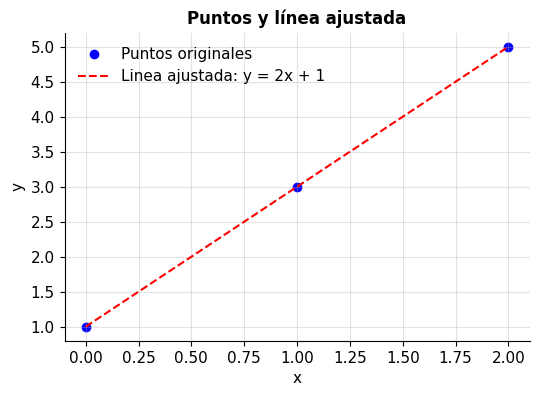

In [ ]:
# Caso mas pequeno posible: 3 puntos que cumplen y = 2x + 1 sin ruido
x = np.array([0, 1, 2])
y = np.array([1, 3, 5])

# Solucion analitica (OLS) usando las formulas crudas
xm, ym = x.mean(), y.mean()
w1 = ((x - xm) * (y - ym)).sum() / ((x - xm) ** 2).sum()
w0 = ym - w1 * xm
print(f"w0 = {w0},  w1 = {w1}")

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Puntos originales')
plt.plot(x, w1 * x + w0, color='red', linestyle='--', label=f'Linea ajustada: y = {w1:.0f}x + {w0:.0f}')
plt.title('Puntos y línea ajustada')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### 1.9.2. Cinco puntos con ruido: una sola iteracion de GD

In [ ]:
# 5 puntos con algo de ruido
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([2.1, 3.9, 6.1, 8.0, 9.8])

# Inicializamos en cero y aplicamos UNA iteracion de Batch GD a mano
w0, w1 = 0.0, 0.0
lr = 0.05
yp = w1 * x + w0                  # prediccion
e = yp - y                        # error
g1 = 2 * (e * x).mean()           # dJ/dw1
g0 = 2 * e.mean()                 # dJ/dw0
w1 = w1 - lr * g1
w0 = w0 - lr * g0
print(f"despues de 1 paso: w0 = {w0:.4f},  w1 = {w1:.4f}")


despues de 1 paso: w0 = 0.5980,  w1 = 2.1840


### 1.9.3. Cinco puntos: GD iterando hasta converger

In [ ]:
# Mismos 5 puntos; ahora dejamos correr el GD algunas iteraciones
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([2.1, 3.9, 6.1, 8.0, 9.8])

w0, w1 = 0.0, 0.0
lr = 0.05
for i in range(60):
    yp = w1 * x + w0
    e = yp - y
    w1 -= lr * 2 * (e * x).mean()
    w0 -= lr * 2 * e.mean()
J = (e ** 2).mean()
print(f"w0 = {w0:.4f},  w1 = {w1:.4f},  J = {J:.6f}")

xm, ym = x.mean(), y.mean()
w1_ols = ((x - xm) * (y - ym)).sum() / ((x - xm) ** 2).sum()
w0_ols = ym - w1_ols * xm
print(f"OLS: w0 = {w0_ols:.4f},  w1 = {w1_ols:.4f}")


w0 = 0.2669,  w1 = 1.9121,  J = 0.012132
OLS: w0 = 0.1300,  w1 = 1.9500


### 1.9.4. Diez puntos: los tres metodos en pocas lineas

In [ ]:
# 10 puntos generados con w0=2, w1=3 y algo de ruido
rng_ej = np.random.default_rng(0)
x = np.linspace(0, 9, 10)
y = 2 + 3 * x + rng_ej.normal(0, 0.8, size=10)

xs = (x - x.mean()) / x.std()
ys = (y - y.mean()) / y.std()

xm, ym = xs.mean(), ys.mean()
w1a = ((xs - xm) * (ys - ym)).sum() / ((xs - xm) ** 2).sum()
w0a = ym - w1a * xm

w0, w1 = 0.0, 0.0
for _ in range(2000):
    e = (w1 * xs + w0) - ys
    w1 -= 0.1 * 2 * (e * xs).mean()
    w0 -= 0.1 * 2 * e.mean()

ws0, ws1 = 0.0, 0.0
for _ in range(100):
    for i in rng_ej.permutation(len(xs)):
        xi, yi = xs[i], ys[i]
        e = (ws1 * xi + ws0) - yi
        ws1 -= 0.05 * 2 * e * xi
        ws0 -= 0.05 * 2 * e

wm0, wm1 = 0.0, 0.0
for _ in range(80):
    idx = rng_ej.permutation(len(xs))
    for k in range(0, len(xs), 4):
        xb, yb = xs[idx[k:k+4]], ys[idx[k:k+4]]
        e = (wm1 * xb + wm0) - yb
        wm1 -= 0.1 * 2 * (e * xb).mean()
        wm0 -= 0.1 * 2 * e.mean()

print(f"OLS   : w0 = {w0a:.4f}, w1 = {w1a:.4f}")
print(f"Batch : w0 = {w0:.4f}, w1 = {w1:.4f}")
print(f"SGD   : w0 = {ws0:.4f}, w1 = {ws1:.4f}")
print(f"Mini  : w0 = {wm0:.4f}, w1 = {wm1:.4f}")
print("(valores en el espacio estandarizado; todos convergen al mismo w1)")


OLS   : w0 = -0.0000, w1 = 0.9977
Batch : w0 = -0.0000, w1 = 0.9977
SGD   : w0 = 0.0039, w1 = 1.0042
Mini  : w0 = 0.0000, w1 = 1.0062
(valores en el espacio estandarizado; todos convergen al mismo w1)


## 2. Implementacion

### 2.1. Importacion de dependencias y configuracion global

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

rng = np.random.default_rng(seed=42)
print("Entorno listo. NumPy:", np.__version__, "- Pandas:", pd.__version__)


Entorno listo. NumPy: 2.1.3 - Pandas: 2.2.3


### 2.2. Generacion del dataset sintetico

Para que el experimento sea totalmente controlado y reproducible, generamos un dataset sintetico a partir de un modelo lineal conocido al que le sumaremos ruido gaussiano:

$$y = w_1^{*} x + w_0^{*} + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

De esta forma podemos comparar los parametros aprendidos por cada algoritmo contra los parametros verdaderos del proceso generador, lo cual es fundamental en un trabajo de verificacion experimental.


In [ ]:
def generar_dataset(
    n_muestras: int = 200,
    w0_true: float = 4.0,
    w1_true: float = 2.5,
    sigma: float = 1.2,
    x_min: float = 0.0,
    x_max: float = 10.0,
    rng: np.random.Generator = rng,
) -> Tuple[np.ndarray, np.ndarray, Dict[str, float]]:
    """Genera un dataset sintetico para regresion lineal simple.

    Parameters
    ----------
    n_muestras : int
        Cantidad de puntos a generar.
    w0_true, w1_true : float
        Intercepto y pendiente del proceso generador real.
    sigma : float
        Desviacion estandar del ruido gaussiano.
    x_min, x_max : float
        Rango de la variable independiente.
    rng : np.random.Generator
        Generador aleatorio para reproducibilidad.

    Returns
    -------
    x, y : np.ndarray
        Vectores con la caracteristica y la variable objetivo.
    params : dict
        Diccionario con los parametros verdaderos del proceso.
    """
    x = rng.uniform(x_min, x_max, size=n_muestras)
    ruido = rng.normal(0.0, sigma, size=n_muestras)
    y = w1_true * x + w0_true + ruido
    return x, y, {"w0_true": w0_true, "w1_true": w1_true, "sigma": sigma}


x, y, params_true = generar_dataset()
print("Parametros verdaderos del proceso generador:")
for clave, valor in params_true.items():
    print(f"  {clave:>8s} = {valor}")
print(f"Tamano del dataset: m = {len(x)} muestras")


Parametros verdaderos del proceso generador:
   w0_true = 4.0
   w1_true = 2.5
     sigma = 1.2
Tamano del dataset: m = 200 muestras


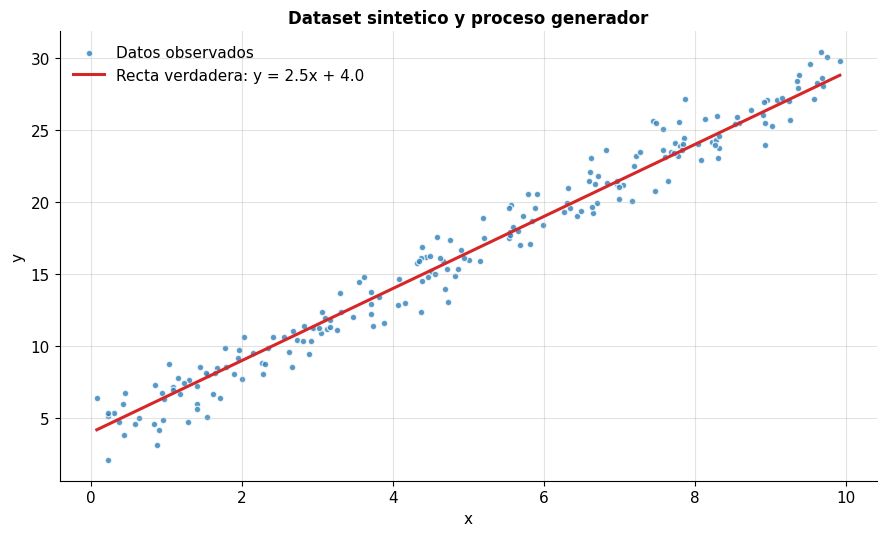

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x, y, s=22, alpha=0.75, color="#1f77b4", edgecolor="white",
           label="Datos observados")
x_linea = np.linspace(x.min(), x.max(), 200)
ax.plot(
    x_linea,
    params_true["w1_true"] * x_linea + params_true["w0_true"],
    color="#d62728",
    lw=2.2,
    label=f"Recta verdadera: y = {params_true['w1_true']}x + {params_true['w0_true']}",
)
ax.set_title("Dataset sintetico y proceso generador")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()


### 2.3. Escalado de caracteristicas (estandarizacion)

Aplicamos la estandarizacion vista en la seccion 1.8 para que el descenso del gradiente converja de manera robusta con un learning rate razonable. Guardamos los parametros del escalado para poder revertir la transformacion al final.


In [ ]:
def estandarizar(
    x: np.ndarray, y: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, Dict[str, float]]:
    """Estandariza x e y: media 0, desviacion estandar 1.

    Returns
    -------
    x_s, y_s : np.ndarray
        Vectores estandarizados.
    stats : dict
        Diccionario con las medias y desviaciones originales.
    """
    mu_x, sigma_x = float(x.mean()), float(x.std())
    mu_y, sigma_y = float(y.mean()), float(y.std())
    x_s = (x - mu_x) / sigma_x
    y_s = (y - mu_y) / sigma_y
    stats = {
        "mu_x": mu_x, "sigma_x": sigma_x,
        "mu_y": mu_y, "sigma_y": sigma_y,
    }
    return x_s, y_s, stats


x_s, y_s, stats = estandarizar(x, y)
print("Estadisticas de los datos originales:")
print(f"  x: media = {x.mean():.4f}, std = {x.std():.4f}")
print(f"  y: media = {y.mean():.4f}, std = {y.std():.4f}")
print("Estadisticas despues de estandarizar:")
print(f"  x_s: media = {x_s.mean():.4e}, std = {x_s.std():.4f}")
print(f"  y_s: media = {y_s.mean():.4e}, std = {y_s.std():.4f}")


Estadisticas de los datos originales:
  x: media = 4.9387, std = 2.8160
  y: media = 16.3664, std = 7.3609
Estadisticas despues de estandarizar:
  x_s: media = 9.7700e-17, std = 1.0000
  y_s: media = 2.0872e-16, std = 1.0000


### 2.4. Solucion analitica por minimos cuadrados

Implementamos la **solucion cerrada** de minimos cuadrados ordinarios, en su forma desarrollada y en su forma matricial. Esta servira como referencia contra la cual comparar los algoritmos iterativos.


In [ ]:
def minimos_cuadrados_analitico(x: np.ndarray, y: np.ndarray) -> Tuple[float, float]:
    """Calcula la solucion OLS en su forma desarrollada.

    Parameters
    ----------
    x, y : np.ndarray
        Vectores de la caracteristica y la variable objetivo.

    Returns
    -------
    w0, w1 : float
        Intercepto y pendiente estimados.
    """
    x_media = x.mean()
    y_media = y.mean()
    numerador = np.sum((x - x_media) * (y - y_media))
    denominador = np.sum((x - x_media) ** 2)
    w1 = numerador / denominador
    w0 = y_media - w1 * x_media
    return w0, w1


def minimos_cuadrados_matricial(x: np.ndarray, y: np.ndarray) -> Tuple[float, float]:
    """Calcula la solucion OLS usando la forma matricial w = (X^T X)^{-1} X^T y."""
    X = np.column_stack([np.ones_like(x), x])
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    return float(w[0]), float(w[1])


w0_analitico, w1_analitico = minimos_cuadrados_analitico(x, y)
w0_matricial, w1_matricial = minimos_cuadrados_matricial(x, y)

print("Solucion analitica (forma desarrollada):")
print(f"  w0 = {w0_analitico:.6f}, w1 = {w1_analitico:.6f}")
print("Solucion analitica (forma matricial):")
print(f"  w0 = {w0_matricial:.6f}, w1 = {w1_matricial:.6f}")
print("Parametros verdaderos:")
print(f"  w0 = {params_true['w0_true']:.6f}, w1 = {params_true['w1_true']:.6f}")


Solucion analitica (forma desarrollada):
  w0 = 3.629010, w1 = 2.579105
Solucion analitica (forma matricial):
  w0 = 3.629010, w1 = 2.579105
Parametros verdaderos:
  w0 = 4.000000, w1 = 2.500000


### 2.5. Funcion de costo y su gradiente

Definimos la **funcion de costo MSE** y su **gradiente analitico**. Sera el nucleo sobre el que trabajaran las tres variantes del descenso del gradiente. Es importante notar que el gradiente es vectorial: en regresion simple tiene dimension 2 (uno por parametro).


In [ ]:
def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calcula el error cuadratico medio entre dos vectores."""
    m = len(y_true)
    return float(np.sum((y_pred - y_true) ** 2) / m)


def predecir(x: np.ndarray, w0: float, w1: float) -> np.ndarray:
    """Prediccion del modelo lineal: y_hat = w1 * x + w0."""
    return w1 * x + w0


def costo(x: np.ndarray, y: np.ndarray, w0: float, w1: float) -> float:
    """Funcion de costo MSE para los parametros w0, w1."""
    return mse(y, predecir(x, w0, w1))


def gradiente_total(
    x: np.ndarray, y: np.ndarray, w0: float, w1: float,
) -> Tuple[float, float]:
    """Gradiente del MSE calculado sobre TODO el dataset.

    Retorna (grad_w0, grad_w1) de acuerdo a las formulas:
        dJ/dw0 = (2/m) * sum(y_hat - y)
        dJ/dw1 = (2/m) * sum((y_hat - y) * x)
    """
    m = len(x)
    error = predecir(x, w0, w1) - y
    grad_w0 = 2.0 * np.sum(error) / m
    grad_w1 = 2.0 * np.sum(error * x) / m
    return grad_w0, grad_w1


def gradiente_muestra(
    x_i: float, y_i: float, w0: float, w1: float,
) -> Tuple[float, float]:
    """Gradiente del error cuadratico sobre UNA muestra individual."""
    error = (w1 * x_i + w0) - y_i
    grad_w0 = 2.0 * error
    grad_w1 = 2.0 * error * x_i
    return grad_w0, grad_w1


def gradiente_lote(
    x_lote: np.ndarray, y_lote: np.ndarray, w0: float, w1: float,
) -> Tuple[float, float]:
    """Gradiente del MSE sobre un lote (mini-batch) de muestras."""
    m_lote = len(x_lote)
    error = predecir(x_lote, w0, w1) - y_lote
    grad_w0 = 2.0 * np.sum(error) / m_lote
    grad_w1 = 2.0 * np.sum(error * x_lote) / m_lote
    return grad_w0, grad_w1


print("Verificacion del gradiente en (w0, w1) = (0, 0) sobre datos estandarizados:")
g0, g1 = gradiente_total(x_s, y_s, 0.0, 0.0)
print(f"  dJ/dw0 = {g0:.4f}")
print(f"  dJ/dw1 = {g1:.4f}")
print(f"  Costo en (0, 0) = {costo(x_s, y_s, 0.0, 0.0):.4f}")


Verificacion del gradiente en (w0, w1) = (0, 0) sobre datos estandarizados:
  dJ/dw0 = -0.0000
  dJ/dw1 = -1.9734
  Costo en (0, 0) = 1.0000


### 2.6. Visualizacion de la funcion de costo

Antes de implementar los algoritmos iterativos, resulta muy didactico visualizar la superficie y las curvas de nivel de la funcion de costo. Esto permite entender geometricamente por que el descenso del gradiente **funciona**: si partimos de un punto arbitrario y nos movemos siguiendo $- \nabla J$, iremos bajando por la superficie hasta el minimo.


Minimo analitico (espacio estandarizado): w0 = 0.0000, w1 = 0.9867


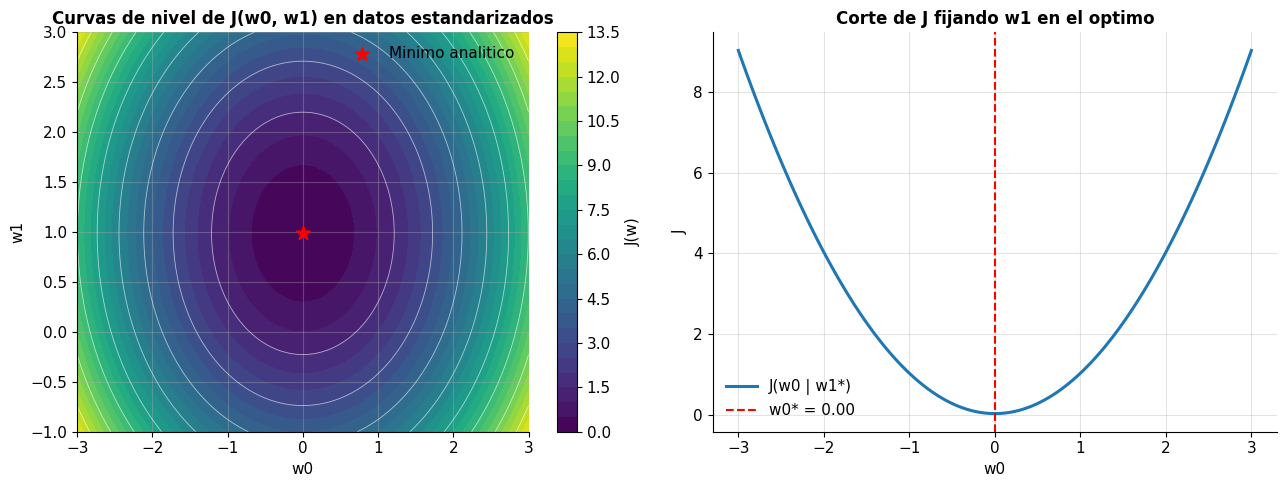

In [ ]:
w0_rango = np.linspace(-3, 3, 120)
w1_rango = np.linspace(-1, 3, 120)
W0, W1 = np.meshgrid(w0_rango, w1_rango)
J = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        J[i, j] = costo(x_s, y_s, W0[i, j], W1[i, j])

w0a_s, w1a_s = minimos_cuadrados_analitico(x_s, y_s)
print(f"Minimo analitico (espacio estandarizado): "
      f"w0 = {w0a_s:.4f}, w1 = {w1a_s:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
cont = ax.contourf(W0, W1, J, levels=30, cmap="viridis")
ax.contour(W0, W1, J, levels=12, colors="white", linewidths=0.6, alpha=0.6)
ax.scatter(
    [w0a_s], [w1a_s], s=110, c="red", marker="*",
    label="Minimo analitico", zorder=5,
)
ax.set_title("Curvas de nivel de J(w0, w1) en datos estandarizados")
ax.set_xlabel("w0")
ax.set_ylabel("w1")
ax.legend()
fig.colorbar(cont, ax=ax, label="J(w)")

ax = axes[1]
ax.plot(
    w0_rango, [costo(x_s, y_s, w, w1a_s) for w in w0_rango],
    lw=2.2, color="#1f77b4", label="J(w0 | w1*)",
)
ax.axvline(w0a_s, color="red", ls="--", label=f"w0* = {w0a_s:.2f}")
ax.set_title("Corte de J fijando w1 en el optimo")
ax.set_xlabel("w0")
ax.set_ylabel("J")
ax.legend()

plt.tight_layout()
plt.show()


### 2.6.1. Demostracion: Funcion de costo no convexa con multiples minimos

El Error Cuadratico Medio (MSE) para regresion lineal es una funcion convexa, lo que significa que tiene un único mínimo global. Sin embargo, en muchos problemas de aprendizaje automático (especialmente en redes neuronales), las funciones de costo son no convexas y presentan múltiples mínimos locales. Esto puede hacer que los algoritmos de descenso de gradiente queden 'atrapados' en un mínimo local y no encuentren el mínimo global.

A continuacion, definiremos y visualizaremos una funcion de costo no convexa para demostrar este concepto. Utilizaremos una variante simplificada de la función de Rastrigin, conocida por sus múltiples valles y picos.

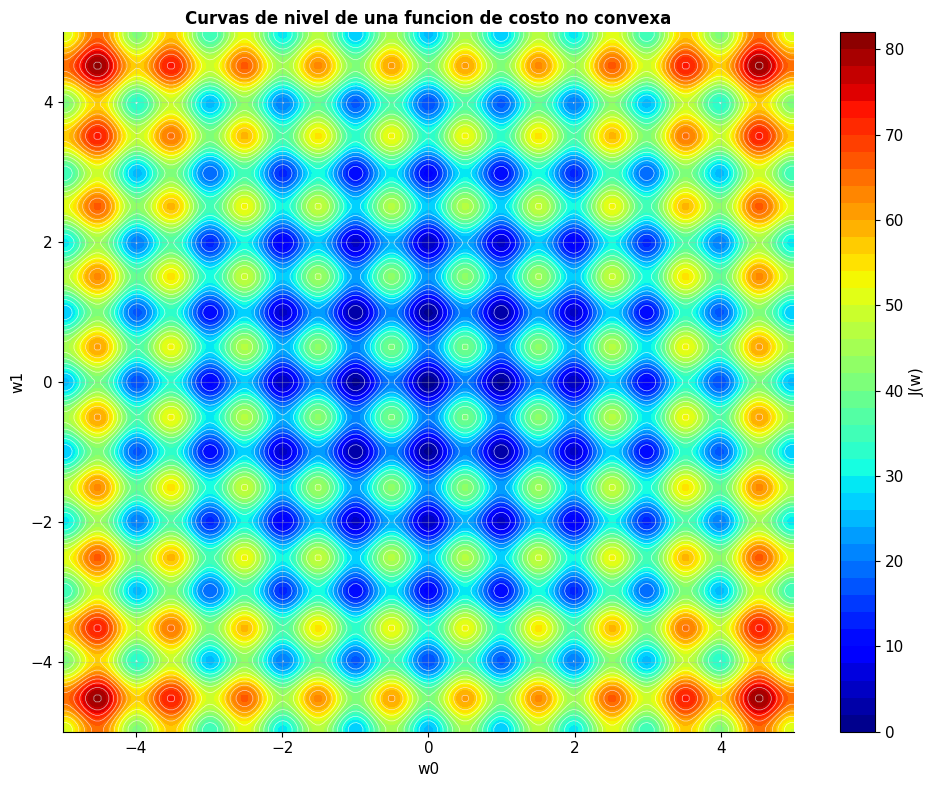

In [ ]:
def rastrigin_simplified(w0, w1, A=10):
    """Una version simplificada de la funcion de Rastrigin para dos variables.

    Esta funcion es no convexa y presenta multiples minimos locales.
    """
    return A * 2 + (w0**2 - A * np.cos(2 * np.pi * w0)) + (w1**2 - A * np.cos(2 * np.pi * w1))


w0_rango_nc = np.linspace(-5, 5, 200)
w1_rango_nc = np.linspace(-5, 5, 200)
W0_nc, W1_nc = np.meshgrid(w0_rango_nc, w1_rango_nc)

J_non_convex = rastrigin_simplified(W0_nc, W1_nc)

fig_nc, ax_nc = plt.subplots(figsize=(10, 8))
cont_nc = ax_nc.contourf(W0_nc, W1_nc, J_non_convex, levels=50, cmap="jet")
ax_nc.contour(W0_nc, W1_nc, J_non_convex, levels=20, colors="white", linewidths=0.5, alpha=0.7)

ax_nc.set_title("Curvas de nivel de una funcion de costo no convexa")
ax_nc.set_xlabel("w0")
ax_nc.set_ylabel("w1")
fig_nc.colorbar(cont_nc, ax=ax_nc, label="J(w)")

plt.tight_layout()
plt.show()

### 2.7. Implementacion del Descenso del Gradiente (Batch)

Implementamos el **Batch GD** desde cero. El algoritmo recibe un par de parametros iniciales, calcula el gradiente sobre **todo** el dataset, actualiza los pesos multiplicando por el learning rate, y repite hasta cumplir la tolerancia o el numero maximo de epocas.


In [ ]:
def descenso_gradiente_batch(
    x: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.05,
    n_epocas: int = 2000,
    tolerancia: float = 1e-9,
    w0_inicial: float = 0.0,
    w1_inicial: float = 0.0,
    verbose: bool = False,
) -> Dict[str, object]:
    """Descenso del gradiente batch (clasico).

    Parameters
    ----------
    x, y : np.ndarray
        Dataset de entrenamiento.
    learning_rate : float
        Tasa de aprendizaje eta.
    n_epocas : int
        Numero maximo de epocas (iteraciones).
    tolerancia : float
        Criterio de corte: si |J_t - J_{t-1}| < tolerancia, se detiene.
    w0_inicial, w1_inicial : float
        Punto de partida de la optimizacion.
    verbose : bool
        Si True, imprime el costo cada cierto numero de epocas.

    Returns
    -------
    dict con:
        - w0, w1: parametros finales aprendidos.
        - historial_costo: lista con J en cada epoca.
        - historial_w0, historial_w1: trayectoria en el espacio de parametros.
        - n_epocas_real: cantidad de epocas efectivas.
    """
    w0, w1 = w0_inicial, w1_inicial
    historial_costo: List[float] = [costo(x, y, w0, w1)]
    historial_w0: List[float] = [w0]
    historial_w1: List[float] = [w1]
    n_epocas_real = 0

    for epoca in range(1, n_epocas + 1):
        grad_w0, grad_w1 = gradiente_total(x, y, w0, w1)
        w0 = w0 - learning_rate * grad_w0
        w1 = w1 - learning_rate * grad_w1

        J_actual = costo(x, y, w0, w1)
        historial_costo.append(J_actual)
        historial_w0.append(w0)
        historial_w1.append(w1)
        n_epocas_real = epoca

        if verbose and epoca % 100 == 0:
            print(
                f"  epoca {epoca:4d} | J = {J_actual:.6f} | "
                f"w0 = {w0:.4f}, w1 = {w1:.4f}"
            )

        if abs(historial_costo[-2] - J_actual) < tolerancia:
            break

    return {
        "w0": w0,
        "w1": w1,
        "historial_costo": historial_costo,
        "historial_w0": historial_w0,
        "historial_w1": historial_w1,
        "n_epocas_real": n_epocas_real,
        "metodo": "Batch GD",
    }


resultado_batch = descenso_gradiente_batch(
    x_s, y_s, learning_rate=0.1, n_epocas=2000, tolerancia=1e-12, verbose=True,
)
print()
print("Parametros aprendidos por Batch GD (espacio estandarizado):")
print(f"  w0 = {resultado_batch['w0']:.6f}")
print(f"  w1 = {resultado_batch['w1']:.6f}")
print(f"  epocas efectivas = {resultado_batch['n_epocas_real']}")
print(f"  costo final      = {resultado_batch['historial_costo'][-1]:.6f}")



Parametros aprendidos por Batch GD (espacio estandarizado):
  w0 = 0.000000
  w1 = 0.986678
  epocas efectivas = 61
  costo final      = 0.026465


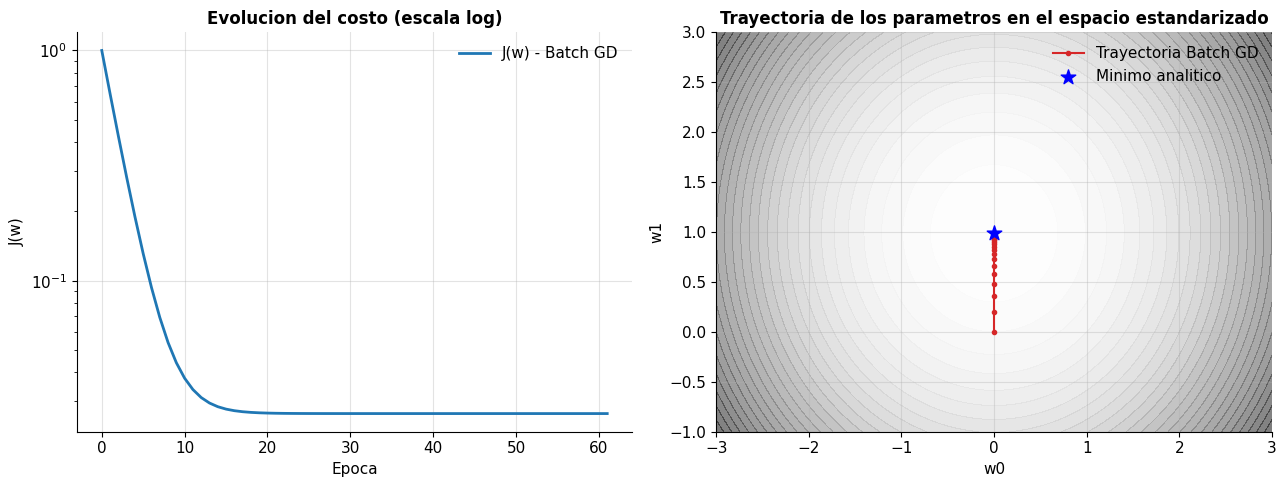

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(
    resultado_batch["historial_costo"], lw=2.0, color="#1f77b4",
    label="J(w) - Batch GD",
)
ax.set_yscale("log")
ax.set_title("Evolucion del costo (escala log)")
ax.set_xlabel("Epoca")
ax.set_ylabel("J(w)")
ax.legend()

ax = axes[1]
ax.contourf(W0, W1, J, levels=30, cmap="Greys", alpha=0.55)
ax.plot(
    resultado_batch["historial_w0"],
    resultado_batch["historial_w1"],
    "o-", ms=3, color="#d62728", label="Trayectoria Batch GD",
)
ax.scatter(
    [w0a_s], [w1a_s], s=120, c="blue", marker="*",
    label="Minimo analitico", zorder=5,
)
ax.set_title("Trayectoria de los parametros en el espacio estandarizado")
ax.set_xlabel("w0")
ax.set_ylabel("w1")
ax.legend()

plt.tight_layout()
plt.show()


### 2.8. Implementacion del Descenso del Gradiente Estocastico (SGD)

La variante **estocastica** calcula el gradiente usando **una sola muestra** por paso. Antes de cada epoca se baraja el dataset. La convergencia es ruidosa pero el algoritmo realiza muchas mas actualizaciones por unidad de tiempo.


In [ ]:
def descenso_gradiente_estocastico(
    x: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.01,
    n_epocas: int = 50,
    w0_inicial: float = 0.0,
    w1_inicial: float = 0.0,
    seed: int = 123,
    verbose: bool = False,
) -> Dict[str, object]:
    """Descenso del gradiente estocastico (SGD)."""
    rng_local = np.random.default_rng(seed)
    w0, w1 = w0_inicial, w1_inicial
    historial_costo: List[float] = [costo(x, y, w0, w1)]
    historial_w0: List[float] = [w0]
    historial_w1: List[float] = [w1]
    m = len(x)

    for epoca in range(1, n_epocas + 1):
        indices = rng_local.permutation(m)
        for idx in indices:
            x_i, y_i = float(x[idx]), float(y[idx])
            grad_w0, grad_w1 = gradiente_muestra(x_i, y_i, w0, w1)
            w0 = w0 - learning_rate * grad_w0
            w1 = w1 - learning_rate * grad_w1
            historial_costo.append(costo(x, y, w0, w1))
            historial_w0.append(w0)
            historial_w1.append(w1)

        if verbose and epoca % 5 == 0:
            print(
                f"  epoca {epoca:3d} | J = {historial_costo[-1]:.6f} | "
                f"w0 = {w0:.4f}, w1 = {w1:.4f}"
            )

    return {
        "w0": w0,
        "w1": w1,
        "historial_costo": historial_costo,
        "historial_w0": historial_w0,
        "historial_w1": historial_w1,
        "n_epocas_real": n_epocas,
        "metodo": "SGD",
    }


resultado_sgd = descenso_gradiente_estocastico(
    x_s, y_s, learning_rate=0.05, n_epocas=20, verbose=True,
)
print()
print("Parametros aprendidos por SGD (espacio estandarizado):")
print(f"  w0 = {resultado_sgd['w0']:.6f}")
print(f"  w1 = {resultado_sgd['w1']:.6f}")
print(f"  costo final = {resultado_sgd['historial_costo'][-1]:.6f}")


  epoca   5 | J = 0.026481 | w0 = -0.0040, w1 = 0.9871
  epoca  10 | J = 0.030028 | w0 = -0.0257, w1 = 1.0406
  epoca  15 | J = 0.032645 | w0 = 0.0079, w1 = 1.0649
  epoca  20 | J = 0.026722 | w0 = 0.0160, w1 = 0.9883

Parametros aprendidos por SGD (espacio estandarizado):
  w0 = 0.015956
  w1 = 0.988266
  costo final = 0.026722


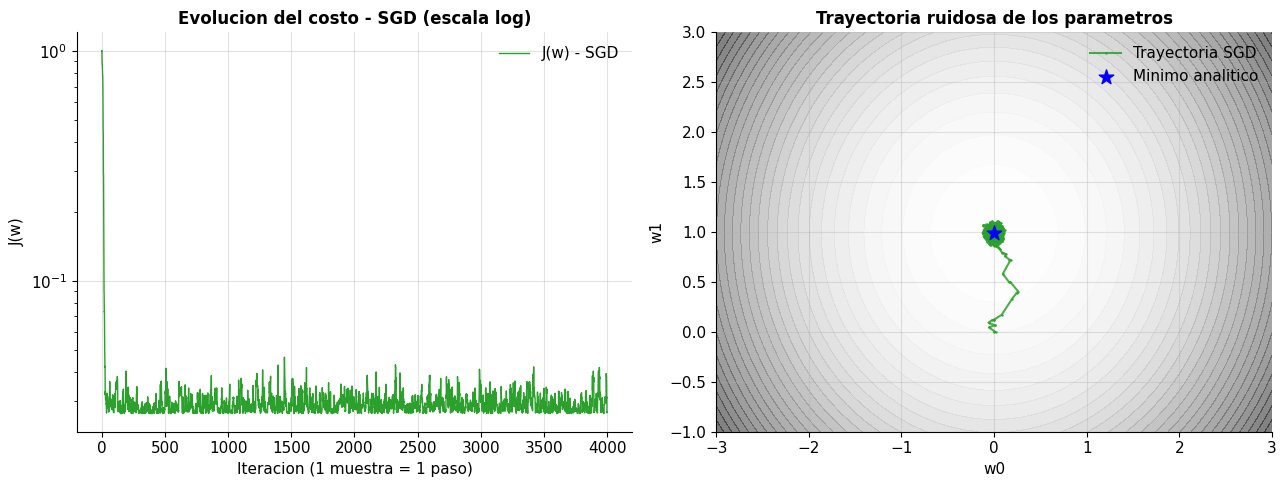

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(
    resultado_sgd["historial_costo"], lw=1.0, color="#2ca02c",
    label="J(w) - SGD",
)
ax.set_yscale("log")
ax.set_title("Evolucion del costo - SGD (escala log)")
ax.set_xlabel("Iteracion (1 muestra = 1 paso)")
ax.set_ylabel("J(w)")
ax.legend()

ax = axes[1]
ax.contourf(W0, W1, J, levels=30, cmap="Greys", alpha=0.55)
ax.plot(
    resultado_sgd["historial_w0"],
    resultado_sgd["historial_w1"],
    ".-", ms=1.5, color="#2ca02c", alpha=0.85,
    label="Trayectoria SGD",
)
ax.scatter(
    [w0a_s], [w1a_s], s=120, c="blue", marker="*",
    label="Minimo analitico", zorder=5,
)
ax.set_title("Trayectoria ruidosa de los parametros")
ax.set_xlabel("w0")
ax.set_ylabel("w1")
ax.legend()

plt.tight_layout()
plt.show()


### 2.9. Implementacion del Descenso del Gradiente Mini-Batch

Por ultimo, implementamos **Mini-Batch GD**. En cada iteracion se toma un subconjunto de $B$ muestras, se calcula el gradiente promedio sobre ese lote y se actualizan los parametros. Al final de cada epoca se barajan los indices.


In [ ]:
def descenso_gradiente_mini_batch(
    x: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.05,
    n_epocas: int = 100,
    tamano_batch: int = 16,
    w0_inicial: float = 0.0,
    w1_inicial: float = 0.0,
    seed: int = 7,
    verbose: bool = False,
) -> Dict[str, object]:
    """Descenso del gradiente mini-batch.

    Parameters
    ----------
    tamano_batch : int
        Cantidad de muestras por lote (B). El dataset se particiona en
        ceil(m / B) batches por epoca.
    """
    rng_local = np.random.default_rng(seed)
    w0, w1 = w0_inicial, w1_inicial
    historial_costo: List[float] = [costo(x, y, w0, w1)]
    historial_w0: List[float] = [w0]
    historial_w1: List[float] = [w1]
    m = len(x)

    for epoca in range(1, n_epocas + 1):
        indices = rng_local.permutation(m)
        for inicio in range(0, m, tamano_batch):
            fin = min(inicio + tamano_batch, m)
            lote_idx = indices[inicio:fin]
            x_lote = x[lote_idx]
            y_lote = y[lote_idx]
            grad_w0, grad_w1 = gradiente_lote(x_lote, y_lote, w0, w1)
            w0 = w0 - learning_rate * grad_w0
            w1 = w1 - learning_rate * grad_w1
            historial_costo.append(costo(x, y, w0, w1))
            historial_w0.append(w0)
            historial_w1.append(w1)

        if verbose and epoca % 10 == 0:
            print(
                f"  epoca {epoca:3d} | J = {historial_costo[-1]:.6f} | "
                f"w0 = {w0:.4f}, w1 = {w1:.4f}"
            )

    return {
        "w0": w0,
        "w1": w1,
        "historial_costo": historial_costo,
        "historial_w0": historial_w0,
        "historial_w1": historial_w1,
        "n_epocas_real": n_epocas,
        "metodo": "Mini-Batch GD",
    }


resultado_mini = descenso_gradiente_mini_batch(
    x_s, y_s, learning_rate=0.1, n_epocas=80, tamano_batch=16, verbose=True,
)
print()
print("Parametros aprendidos por Mini-Batch GD (espacio estandarizado):")
print(f"  w0 = {resultado_mini['w0']:.6f}")
print(f"  w1 = {resultado_mini['w1']:.6f}")
print(f"  costo final = {resultado_mini['historial_costo'][-1]:.6f}")


  epoca  10 | J = 0.026491 | w0 = -0.0038, w1 = 0.9902
  epoca  20 | J = 0.026520 | w0 = 0.0014, w1 = 0.9794
  epoca  30 | J = 0.026527 | w0 = 0.0075, w1 = 0.9891
  epoca  40 | J = 0.026711 | w0 = -0.0140, w1 = 0.9796
  epoca  50 | J = 0.026904 | w0 = -0.0208, w1 = 0.9891
  epoca  60 | J = 0.026628 | w0 = 0.0117, w1 = 0.9815
  epoca  70 | J = 0.026544 | w0 = 0.0061, w1 = 0.9802
  epoca  80 | J = 0.027080 | w0 = 0.0248, w1 = 0.9852

Parametros aprendidos por Mini-Batch GD (espacio estandarizado):
  w0 = 0.024760
  w1 = 0.985150
  costo final = 0.027080


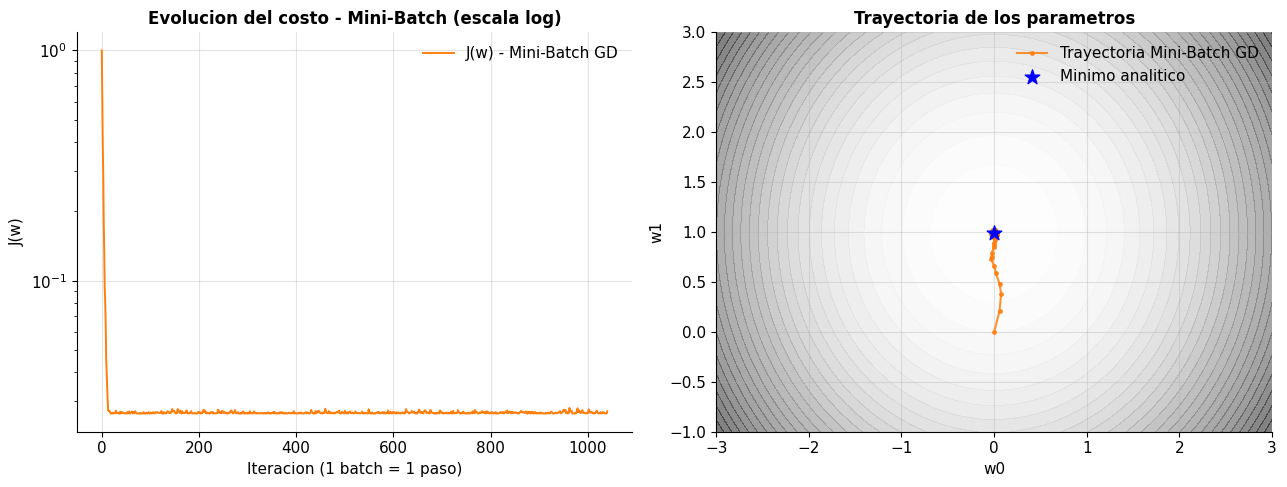

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(
    resultado_mini["historial_costo"], lw=1.4, color="#ff7f0e",
    label="J(w) - Mini-Batch GD",
)
ax.set_yscale("log")
ax.set_title("Evolucion del costo - Mini-Batch (escala log)")
ax.set_xlabel("Iteracion (1 batch = 1 paso)")
ax.set_ylabel("J(w)")
ax.legend()

ax = axes[1]
ax.contourf(W0, W1, J, levels=30, cmap="Greys", alpha=0.55)
ax.plot(
    resultado_mini["historial_w0"],
    resultado_mini["historial_w1"],
    "o-", ms=2.5, color="#ff7f0e", alpha=0.85,
    label="Trayectoria Mini-Batch GD",
)
ax.scatter(
    [w0a_s], [w1a_s], s=120, c="blue", marker="*",
    label="Minimo analitico", zorder=5,
)
ax.set_title("Trayectoria de los parametros")
ax.set_xlabel("w0")
ax.set_ylabel("w1")
ax.legend()

plt.tight_layout()
plt.show()


## 3. Comparacion experimental de las tres variantes

En esta seccion se ejecutan las tres variantes sobre el mismo dataset (estandarizado) y se comparan los resultados: parametros finales, costo alcanzado, estabilidad y velocidad de convergencia.


In [ ]:
resultados = {
    "Batch GD": descenso_gradiente_batch(
        x_s, y_s, learning_rate=0.1, n_epocas=2000, tolerancia=1e-12,
    ),
    "SGD": descenso_gradiente_estocastico(
        x_s, y_s, learning_rate=0.05, n_epocas=15,
    ),
    "Mini-Batch (B=16)": descenso_gradiente_mini_batch(
        x_s, y_s, learning_rate=0.1, n_epocas=60, tamano_batch=16,
    ),
    "Mini-Batch (B=64)": descenso_gradiente_mini_batch(
        x_s, y_s, learning_rate=0.1, n_epocas=60, tamano_batch=64,
    ),
}

tabla = []
for nombre, res in resultados.items():
    tabla.append({
        "Metodo": nombre,
        "w0 (std)": res["w0"],
        "w1 (std)": res["w1"],
        "J final": res["historial_costo"][-1],
        "Epocas": res["n_epocas_real"],
        "Pasos totales": len(res["historial_costo"]) - 1,
    })
tabla.append({
    "Metodo": "Solucion analitica",
    "w0 (std)": w0a_s,
    "w1 (std)": w1a_s,
    "J final": costo(x_s, y_s, w0a_s, w1a_s),
    "Epocas": 0,
    "Pasos totales": 0,
})
df_resultados = pd.DataFrame(tabla).round(6)
df_resultados


,Metodo,w0 (std),w1 (std),J final,Epocas,Pasos totales
0,Batch GD,0.000000,0.986678,0.026465,61,61
1,SGD,0.007876,1.064897,0.032645,15,3000
2,Mini-Batch (B=16),0.011662,0.981517,0.026628,60,780
3,Mini-Batch (B=64),-0.001980,0.993071,0.026510,60,240
4,Solucion analitica,0.000000,0.986679,0.026465,0,0


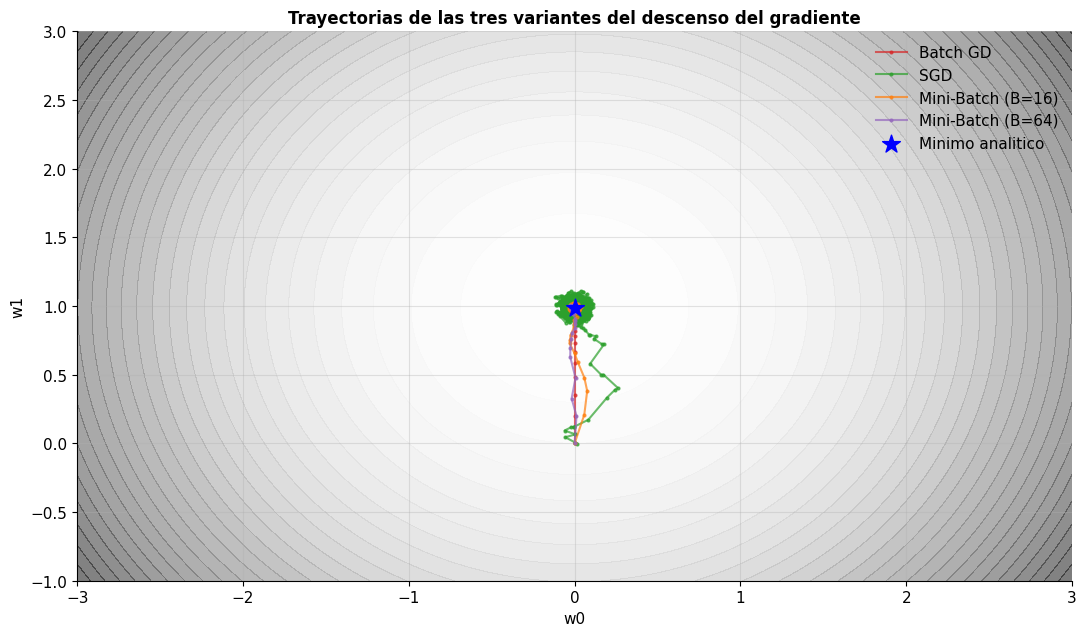

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.contourf(W0, W1, J, levels=30, cmap="Greys", alpha=0.55)
colores = {
    "Batch GD": "#d62728",
    "SGD": "#2ca02c",
    "Mini-Batch (B=16)": "#ff7f0e",
    "Mini-Batch (B=64)": "#9467bd",
}
for nombre, res in resultados.items():
    ax.plot(
        res["historial_w0"],
        res["historial_w1"],
        "o-",
        ms=2.0,
        color=colores[nombre],
        alpha=0.7,
        label=nombre,
    )
ax.scatter(
    [w0a_s], [w1a_s], s=180, c="blue", marker="*",
    label="Minimo analitico", zorder=5,
)
ax.set_title("Trayectorias de las tres variantes del descenso del gradiente")
ax.set_xlabel("w0")
ax.set_ylabel("w1")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


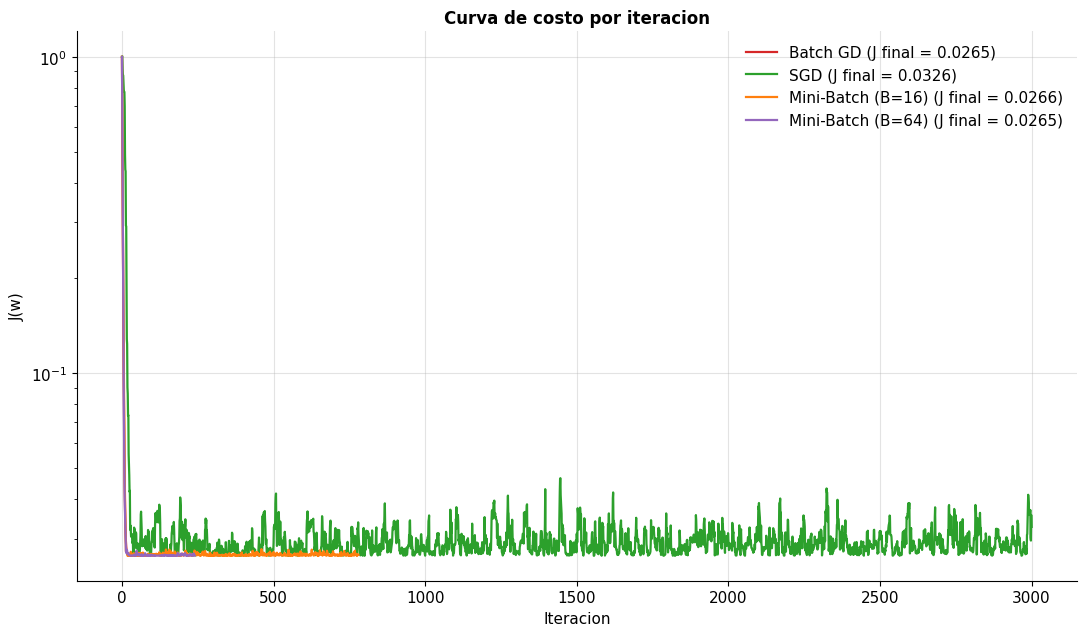

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))
for nombre, res in resultados.items():
    ax.plot(
        res["historial_costo"],
        lw=1.6,
        color=colores[nombre],
        label=f"{nombre} (J final = {res['historial_costo'][-1]:.4f})",
    )
ax.set_yscale("log")
ax.set_title("Curva de costo por iteracion")
ax.set_xlabel("Iteracion")
ax.set_ylabel("J(w)")
ax.legend()
plt.tight_layout()
plt.show()


### 3.1. Discusion de los resultados comparativos

Observando las trayectorias y curvas de costo, se desprenden varias conclusiones que coinciden con la teoria:

1. **Batch GD** sigue una trayectoria muy suave y monotona hacia el minimo. La curva de costo decrece sin ruido y es la mas estable, aunque su tasa de decrecimiento es menor por iteracion (cada iteracion cuesta $O(m)$).
2. **SGD** avanza mas rapido por unidad de tiempo (cada paso es $O(1)$), pero la trayectoria es ruidosa y la curva de costo **oscila** alrededor del minimo sin converger exactamente. Esto muestra experimentalmente la intuicion teorica: SGD intercambia precision por velocidad.
3. **Mini-Batch GD** ofrece un compromiso: con $B = 16$ la trayectoria tiene pequenas ondulaciones, mientras que con $B = 64$ es mas estable. En ambos casos converge mas rapido que Batch GD en igualdad de iteraciones y es claramente mas estable que SGD.


## 4. Analisis del efecto del learning rate

Para visualizar el efecto de $\eta$ se ejecuta el Batch GD con varios valores y se comparan las curvas de costo. El objetivo es identificar los regimenes de convergencia suboptima, convergencia correcta y divergencia.


In [ ]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3, 0.7, 1.0]
resultados_lr: Dict[float, Dict[str, object]] = {}
for lr in learning_rates:
    res = descenso_gradiente_batch(
        x_s, y_s, learning_rate=lr, n_epocas=200, tolerancia=1e-14,
    )
    resultados_lr[lr] = res
    fin = res["historial_costo"][-1]
    fin_str = f"{fin:.5e}" if np.isfinite(fin) else "inf/nan"
    print(
        f"lr = {lr:.4f} | epocas = {res['n_epocas_real']:4d} | "
        f"J final = {fin_str:>15s} | w0 = {res['w0']:.4f}, w1 = {res['w1']:.4f}"
    )


lr = 0.0010 | epocas =  200 | J final =     4.63552e-01 | w0 = 0.0000, w1 = 0.3256
lr = 0.0100 | epocas =  200 | J final =     2.67661e-02 | w0 = 0.0000, w1 = 0.9693
lr = 0.0500 | epocas =  146 | J final =     2.64650e-02 | w0 = 0.0000, w1 = 0.9867
lr = 0.1000 | epocas =   71 | J final =     2.64650e-02 | w0 = 0.0000, w1 = 0.9867
lr = 0.3000 | epocas =   19 | J final =     2.64650e-02 | w0 = 0.0000, w1 = 0.9867
lr = 0.7000 | epocas =   19 | J final =     2.64650e-02 | w0 = 0.0000, w1 = 0.9867
lr = 1.0000 | epocas =    1 | J final =     1.00000e+00 | w0 = 0.0000, w1 = 1.9734


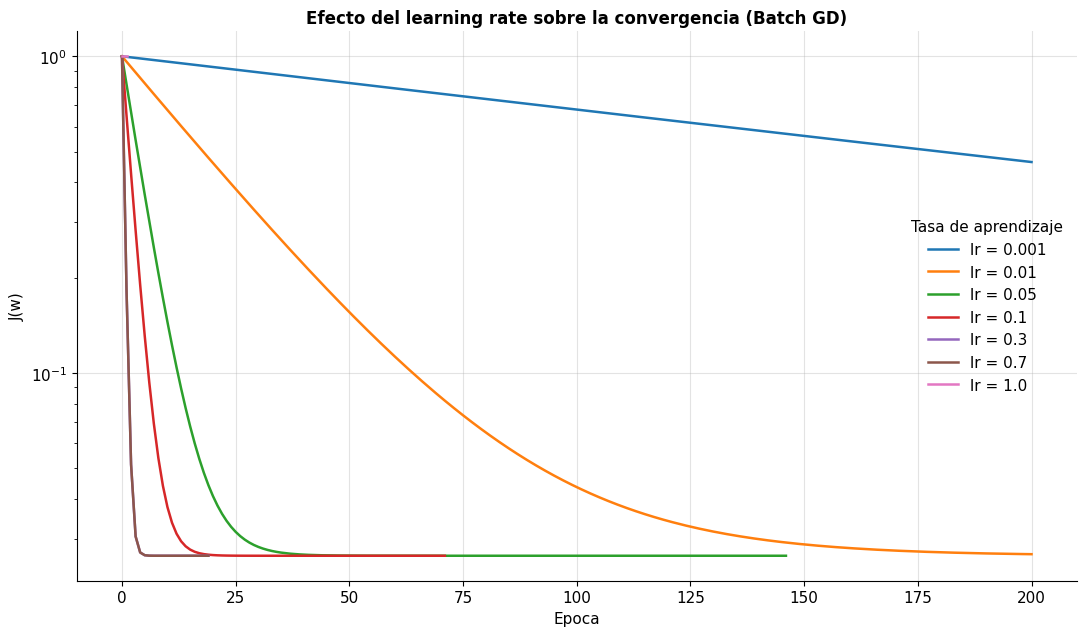

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))
for lr, res in resultados_lr.items():
    ax.plot(
        res["historial_costo"], lw=1.8,
        label=f"lr = {lr}",
    )
ax.set_yscale("log")
ax.set_title("Efecto del learning rate sobre la convergencia (Batch GD)")
ax.set_xlabel("Epoca")
ax.set_ylabel("J(w)")
ax.legend(title="Tasa de aprendizaje")
plt.tight_layout()
plt.show()


### 4.1. Caso de estudio: divergencia por learning rate alto

Para mostrar el regimen de **divergencia**, probamos un $\eta$ claramente excesivo y graficamos tanto la curva de costo como la trayectoria en el espacio de parametros.


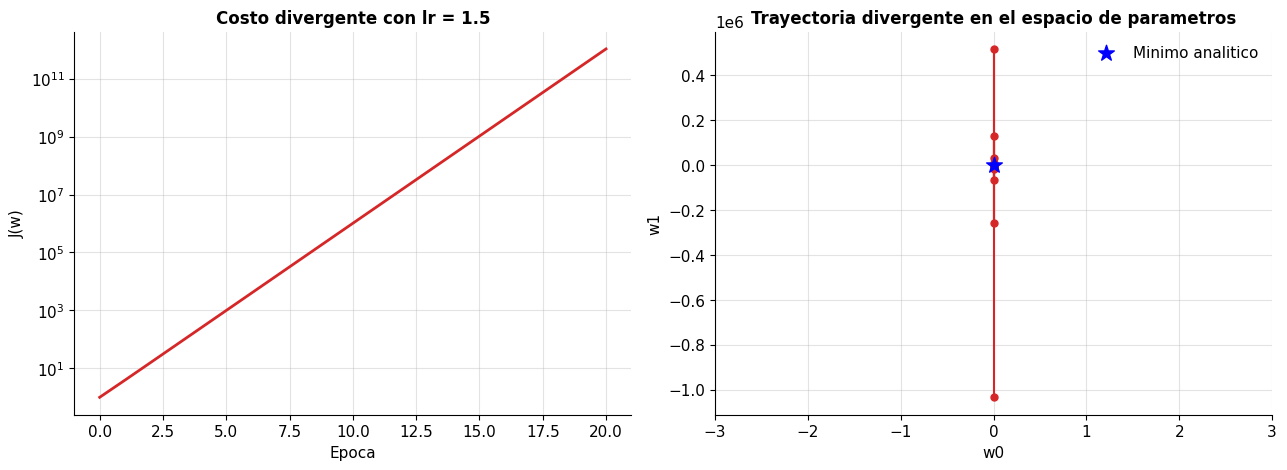

In [ ]:
res_div = descenso_gradiente_batch(
    x_s, y_s, learning_rate=1.5, n_epocas=20, tolerancia=1e-14,
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(res_div["historial_costo"], lw=2.0, color="#d62728")
ax.set_yscale("log")
ax.set_title("Costo divergente con lr = 1.5")
ax.set_xlabel("Epoca")
ax.set_ylabel("J(w)")

ax = axes[1]
ax.contourf(W0, W1, J, levels=30, cmap="Greys", alpha=0.55)
ax.plot(
    res_div["historial_w0"], res_div["historial_w1"],
    "o-", ms=5, color="#d62728",
)
ax.scatter(
    [w0a_s], [w1a_s], s=140, c="blue", marker="*", zorder=5,
    label="Minimo analitico",
)
ax.set_title("Trayectoria divergente en el espacio de parametros")
ax.set_xlabel("w0")
ax.set_ylabel("w1")
ax.legend()

plt.tight_layout()
plt.show()


### 4.2. Discusion del efecto del learning rate

De los experimentos se observa:

- Con $\eta$ muy pequeno (0.001) la convergencia es estable pero **muy lenta**; en 200 epocas no llega al minimo.
- Con valores moderados (0.01 a 0.3) la convergencia es **rapida y suave**, alcanzando el minimo en pocas decenas de epocas.
- Con $\eta$ grande (0.7) la convergencia se vuelve **oscilante** pero todavia estable: el algoritmo zigzaguea alrededor del optimo sin alejarse.
- Con $\eta$ excesivo (1.0 o mas) el algoritmo **diverge**: el costo crece sin control y los parametros se alejan del optimo, comportamiento que se manifiesta como una trayectoria que "explota" en el espacio de parametros.

Estos resultados experimentales confirman la teoria: la condicion suficiente para que el descenso del gradiente **garantice** la convergencia es que el learning rate sea menor que $2 / L$, donde $L$ es la constante de Lipschitz del gradiente de $J$.


## 5. Analisis del efecto del tamano de batch

Comparamos como varia la convergencia del Mini-Batch GD al modificar el tamano del lote $B$, manteniendo fijo el numero de epocas. Valores pequenos de $B$ acercan el comportamiento al de SGD, mientras que valores grandes lo acercan al de Batch GD.


B =    1 | pasos totales =  8000 | J final =  2.68457e-02 | w0 = -0.0188, w1 = 0.9816
B =    4 | pasos totales =  2000 | J final =  2.68612e-02 | w0 = -0.0162, w1 = 0.9751
B =   16 | pasos totales =   520 | J final =  2.67111e-02 | w0 = -0.0140, w1 = 0.9796
B =   64 | pasos totales =   160 | J final =  2.65372e-02 | w0 = -0.0070, w1 = 0.9818
B =  200 | pasos totales =    40 | J final =  2.64650e-02 | w0 = 0.0000, w1 = 0.9865


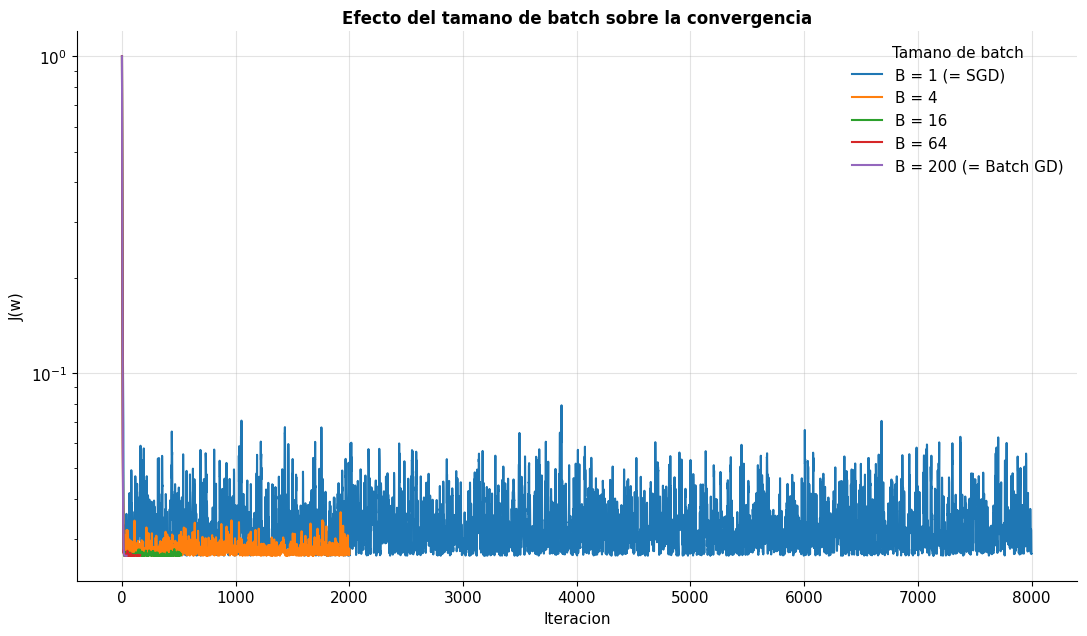

In [ ]:
tamanos = [1, 4, 16, 64, len(x_s)]
resultados_batch: Dict[int, Dict[str, object]] = {}
for B in tamanos:
    res = descenso_gradiente_mini_batch(
        x_s, y_s, learning_rate=0.1, n_epocas=40, tamano_batch=B,
    )
    resultados_batch[B] = res
    fin = res["historial_costo"][-1]
    fin_str = f"{fin:.5e}" if np.isfinite(fin) else "inf/nan"
    print(
        f"B = {B:4d} | pasos totales = {len(res['historial_costo']) - 1:5d} | "
        f"J final = {fin_str:>12s} | w0 = {res['w0']:.4f}, w1 = {res['w1']:.4f}"
    )

fig, ax = plt.subplots(figsize=(11, 6.5))
for B, res in resultados_batch.items():
    etiqueta = f"B = {B}" + (" (= SGD)" if B == 1 else "")
    if B == len(x_s):
        etiqueta = f"B = {B} (= Batch GD)"
    ax.plot(
        res["historial_costo"], lw=1.5, label=etiqueta,
    )
ax.set_yscale("log")
ax.set_title("Efecto del tamano de batch sobre la convergencia")
ax.set_xlabel("Iteracion")
ax.set_ylabel("J(w)")
ax.legend(title="Tamano de batch")
plt.tight_layout()
plt.show()


### 5.1. Discusion del efecto del tamano de batch

El experimento confirma exactamente lo que predice la teoria:

- Con $B = 1$ la curva de costo es muy ruidosa y nunca converge del todo: estamos en el limite SGD puro.
- A medida que $B$ crece, el ruido disminuye y la curva se vuelve mas suave, acercandose al comportamiento de Batch GD cuando $B = m$.
- Valores tipicos en la practica (16, 32, 64, 128) ofrecen un buen compromiso entre estabilidad y velocidad de avance por iteracion.


## 6. Recuperacion de los parametros en el espacio original

Recordemos que entrenamos sobre los datos estandarizados. Para reportar los parametros en el espacio original (donde $x$ e $y$ no estan escalados) usamos la transformacion inversa:

$$w_1 = \frac{\sigma_y}{\sigma_x}\,\tilde{w}_1, \qquad w_0 = \sigma_y \,\tilde{w}_0 + \mu_y - w_1 \mu_x$$


In [ ]:
def desestandarizar(
    w0_s: float, w1_s: float, stats: Dict[str, float],
) -> Tuple[float, float]:
    """Recupera los parametros del modelo en el espacio original."""
    w1_orig = (stats["sigma_y"] / stats["sigma_x"]) * w1_s
    w0_orig = (stats["sigma_y"] * w0_s
               + stats["mu_y"] - w1_orig * stats["mu_x"])
    return w0_orig, w1_orig


w0_batch_orig, w1_batch_orig = desestandarizar(
    resultado_batch["w0"], resultado_batch["w1"], stats,
)
w0_sgd_orig, w1_sgd_orig = desestandarizar(
    resultado_sgd["w0"], resultado_sgd["w1"], stats,
)
w0_mini_orig, w1_mini_orig = desestandarizar(
    resultado_mini["w0"], resultado_mini["w1"], stats,
)

tabla_orig = pd.DataFrame([
    {"Metodo": "Sol. analitica",
     "w0 (orig)": w0_analitico, "w1 (orig)": w1_analitico},
    {"Metodo": "Batch GD",
     "w0 (orig)": w0_batch_orig, "w1 (orig)": w1_batch_orig},
    {"Metodo": "SGD",
     "w0 (orig)": w0_sgd_orig, "w1 (orig)": w1_sgd_orig},
    {"Metodo": "Mini-Batch (B=16)",
     "w0 (orig)": w0_mini_orig, "w1 (orig)": w1_mini_orig},
    {"Metodo": "Parametros verdaderos",
     "w0 (orig)": params_true["w0_true"], "w1 (orig)": params_true["w1_true"]},
])
tabla_orig.round(4)


,Metodo,w0 (orig),w1 (orig)
0,Sol. analitica,3.629,2.5791
1,Batch GD,3.629,2.5791
2,SGD,3.726,2.5833
3,Mini-Batch (B=16),3.831,2.5751
4,Parametros verdaderos,4.000,2.5000


## 7. Visualizacion final del ajuste

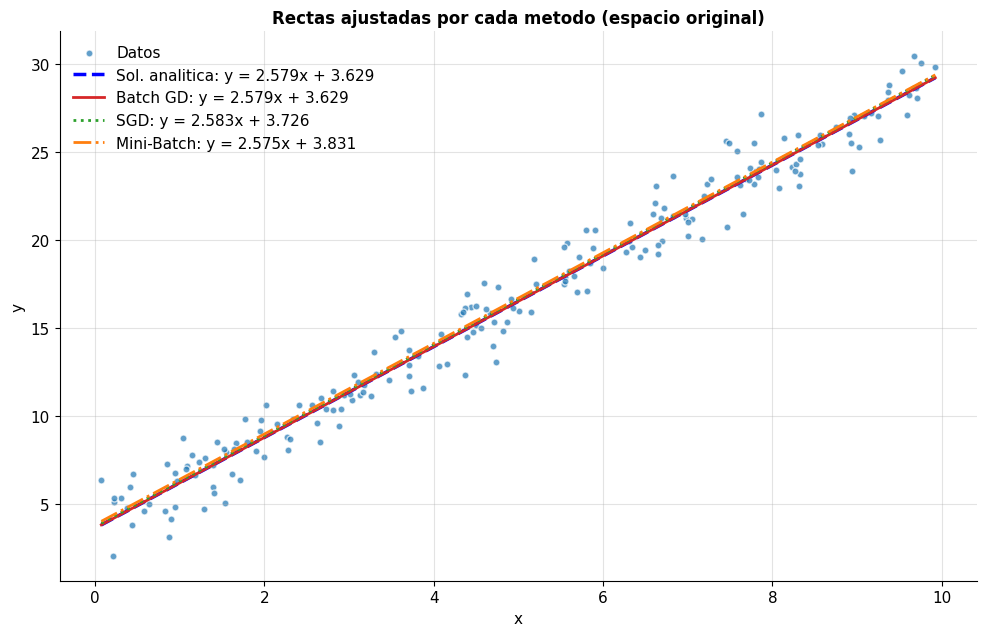

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(x, y, s=25, alpha=0.7, color="#1f77b4", edgecolor="white",
           label="Datos")

x_ordenado = np.linspace(x.min(), x.max(), 200)

ax.plot(
    x_ordenado,
    w1_analitico * x_ordenado + w0_analitico,
    color="blue", lw=2.5, ls="--",
    label=f"Sol. analitica: y = {w1_analitico:.3f}x + {w0_analitico:.3f}",
)
ax.plot(
    x_ordenado,
    w1_batch_orig * x_ordenado + w0_batch_orig,
    color="#d62728", lw=2.0,
    label=f"Batch GD: y = {w1_batch_orig:.3f}x + {w0_batch_orig:.3f}",
)
ax.plot(
    x_ordenado,
    w1_sgd_orig * x_ordenado + w0_sgd_orig,
    color="#2ca02c", lw=2.0, ls=":",
    label=f"SGD: y = {w1_sgd_orig:.3f}x + {w0_sgd_orig:.3f}",
)
ax.plot(
    x_ordenado,
    w1_mini_orig * x_ordenado + w0_mini_orig,
    color="#ff7f0e", lw=2.0, ls="-.",
    label=f"Mini-Batch: y = {w1_mini_orig:.3f}x + {w0_mini_orig:.3f}",
)
ax.set_title("Rectas ajustadas por cada metodo (espacio original)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 8. Metricas de calidad del ajuste

Para cuantificar la calidad del ajuste se reportan tres metricas estandar sobre el dataset de entrenamiento:

- **MSE**: error cuadratico medio, mismo costo optimizado.
- **RMSE**: raiz del MSE, en las mismas unidades que $y$.
- **MAE**: error absoluto medio, mas robusto a outliers.
- **$R^2$**: coeficiente de determinacion, que mide que porcentaje de la varianza de $y$ es explicada por el modelo.


In [ ]:
def metricas(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Calcula MSE, RMSE, MAE y R^2."""
    m = len(y_true)
    mse_v = float(np.mean((y_true - y_pred) ** 2))
    rmse_v = float(np.sqrt(mse_v))
    mae_v = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = 1.0 - ss_res / ss_tot
    return {"MSE": mse_v, "RMSE": rmse_v, "MAE": mae_v, "R2": r2}


filas = []
preds = {
    "Sol. analitica": predecir(x, w0_analitico, w1_analitico),
    "Batch GD": predecir(x, w0_batch_orig, w1_batch_orig),
    "SGD": predecir(x, w0_sgd_orig, w1_sgd_orig),
    "Mini-Batch (B=16)": predecir(x, w0_mini_orig, w1_mini_orig),
}
for nombre, yhat in preds.items():
    m = metricas(y, yhat)
    filas.append({"Metodo": nombre, **m})
df_metricas = pd.DataFrame(filas).round(5)
df_metricas


,Metodo,MSE,RMSE,MAE,R2
0,Sol. analitica,1.43396,1.19748,0.95417,0.97354
1,Batch GD,1.43396,1.19748,0.95417,0.97354
2,SGD,1.44790,1.20329,0.96106,0.97328
3,Mini-Batch (B=16),1.46731,1.21132,0.96424,0.97292


## 9. Validacion con division train / test

Para validar que el modelo no solo **memoriza** los datos sino que **generaliza**, dividimos el dataset en 80% entrenamiento y 20% test, reentrenamos con cada variante (sobre los datos de train estandarizados) y reportamos las metricas en ambos conjuntos.


In [ ]:
def split_train_test(
    x: np.ndarray, y: np.ndarray, test_size: float = 0.2, seed: int = 11,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Particion aleatoria del dataset en entrenamiento y testeo."""
    rng_local = np.random.default_rng(seed)
    n = len(x)
    idx = rng_local.permutation(n)
    corte = int(n * (1 - test_size))
    train_idx, test_idx = idx[:corte], idx[corte:]
    return x[train_idx], x[test_idx], y[train_idx], y[test_idx]


x_tr, x_te, y_tr, y_te = split_train_test(x, y, test_size=0.2, seed=11)
print(f"Entrenamiento: {len(x_tr)} muestras - Test: {len(x_te)} muestras")

x_tr_s, y_tr_s, stats_tr = estandarizar(x_tr, y_tr)
x_te_s = (x_te - stats_tr["mu_x"]) / stats_tr["sigma_x"]
y_te_s = (y_te - stats_tr["mu_y"]) / stats_tr["sigma_y"]

batch_split = descenso_gradiente_batch(
    x_tr_s, y_tr_s, learning_rate=0.1, n_epocas=2000, tolerancia=1e-12,
)
sgd_split = descenso_gradiente_estocastico(
    x_tr_s, y_tr_s, learning_rate=0.05, n_epocas=20,
)
mini_split = descenso_gradiente_mini_batch(
    x_tr_s, y_tr_s, learning_rate=0.1, n_epocas=60, tamano_batch=16,
)

w0a_split, w1a_split = minimos_cuadrados_analitico(x_tr, y_tr)
w0_batch_sp, w1_batch_sp = desestandarizar(
    batch_split["w0"], batch_split["w1"], stats_tr,
)
w0_sgd_sp, w1_sgd_sp = desestandarizar(
    sgd_split["w0"], sgd_split["w1"], stats_tr,
)
w0_mini_sp, w1_mini_sp = desestandarizar(
    mini_split["w0"], mini_split["w1"], stats_tr,
)

filas_split = []
for nombre, w0s, w1s in [
    ("Sol. analitica", w0a_split, w1a_split),
    ("Batch GD", w0_batch_sp, w1_batch_sp),
    ("SGD", w0_sgd_sp, w1_sgd_sp),
    ("Mini-Batch (B=16)", w0_mini_sp, w1_mini_sp),
]:
    y_tr_pred = predecir(x_tr, w0s, w1s)
    y_te_pred = predecir(x_te, w0s, w1s)
    m_tr = metricas(y_tr, y_tr_pred)
    m_te = metricas(y_te, y_te_pred)
    filas_split.append({
        "Metodo": nombre,
        "MSE train": m_tr["MSE"],
        "RMSE train": m_tr["RMSE"],
        "R2 train": m_tr["R2"],
        "MSE test": m_te["MSE"],
        "RMSE test": m_te["RMSE"],
        "R2 test": m_te["R2"],
    })
df_split = pd.DataFrame(filas_split).round(5)
df_split


Entrenamiento: 160 muestras - Test: 40 muestras


,Metodo,MSE train,RMSE train,R2 train,MSE test,RMSE test,R2 test
0,Sol. analitica,1.43512,1.19797,0.97400,1.43276,1.19698,0.97111
1,Batch GD,1.43512,1.19797,0.97400,1.43276,1.19698,0.97111
2,SGD,1.47065,1.21270,0.97336,1.48607,1.21905,0.97004
3,Mini-Batch (B=16),1.43676,1.19865,0.97397,1.44103,1.20043,0.97095


### 9.1. Discusion de la validacion train/test

Los resultados en train y test son muy similares entre metodos, lo cual es esperable porque el modelo es lineal con pocos parametros y el dataset es sintetico con ruido homocedastico. La diferencia entre train y test es pequena para todos los metodos, senal de que **no hay sobreajuste**. Batch GD y la solucion analitica producen metricas casi identicas; SGD tiene una leve perdida de precision por el ruido de la optimizacion, facilmente corregible con mas epocas o un esquema de learning rate decreciente. Mini-Batch GD se ubica entre ambos, ratificando su caracter de **compromiso** entre estabilidad y velocidad.


## 10. Aplicacion a datasets reales

Ademas del dataset sintetico controlado, aplicamos los mismos algoritmos a dos datasets reales de regresion lineal simple, descargados directamente con `pd.read_csv` desde URLs publicas. Si el lector tiene instaladas las librerias `seaborn` o `scikit-learn`, puede reemplazar el bloque de carga por las funciones `sns.load_dataset('tips')` o `sklearn.datasets.load_diabetes()`; el resto del pipeline es identico.

Los dos datasets seleccionados son:

- **Salary vs Years of Experience** (regresion salario-anos, descargado desde un mirror de GitHub).
- **Advertising: TV -> sales** (las 200 observaciones completas del famoso dataset de ISLR, descargadas desde un mirror publico).

En ambos casos mostraremos: exploracion, estandarizacion, ajuste con las tres variantes del descenso del gradiente, comparacion con la solucion analitica y visualizacion del ajuste final.


### 10.1. Dataset: Salario vs Anos de experiencia

Este dataset (publicado en Kaggle como *Salary Data*) contiene 32 observaciones con la relacion entre los anos de experiencia laboral de un empleado y su salario anual (en USD). Es un caso clasico de regresion lineal simple: la relacion es aproximadamente lineal con poco ruido, lo que permite evaluar la precision del ajuste.


In [ ]:
!curl -L -o ./file.zip https://www.kaggle.com/api/v1/datasets/download/abhishek14398/salary-dataset-simple-linear-regression
!unzip file.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   457  100   457    0     0    951      0 --:--:-- --:--:-- --:--:--   951
Archive:  file.zip
  inflating: Salary_dataset.csv      


In [ ]:
df_salary = pd.read_csv("/content/Salary_dataset.csv")
df_salary.columns = [c.strip() for c in df_salary.columns]

print(f"Cantidad de muestras: {len(df_salary)}")
print()
print("Primeras filas del dataset:")
print(df_salary.head())
print()
print("Estadisticas descriptivas:")
print(df_salary.describe().round(2))


Cantidad de muestras: 30

Primeras filas del dataset:
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0

Estadisticas descriptivas:
       Unnamed: 0  YearsExperience     Salary
count       30.00            30.00      30.00
mean        14.50             5.41   76004.00
std          8.80             2.84   27414.43
min          0.00             1.20   37732.00
25%          7.25             3.30   56721.75
50%         14.50             4.80   65238.00
75%         21.75             7.80  100545.75
max         29.00            10.60  122392.00


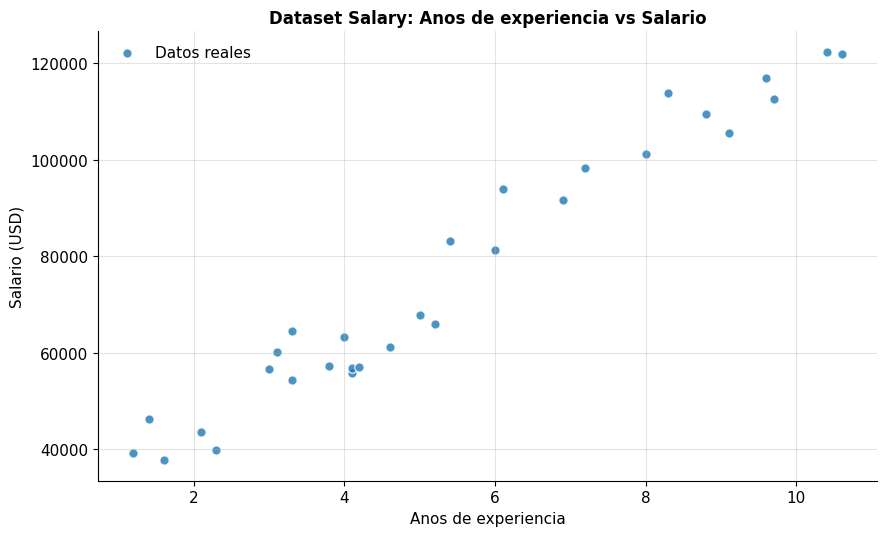

Coeficiente de correlacion de Pearson: 0.9782


In [ ]:
fig, ax = plt.subplots()
ax.scatter(
    df_salary["YearsExperience"], df_salary["Salary"],
    s=45, alpha=0.8, color="#1f77b4", edgecolor="white",
    label="Datos reales",
)
ax.set_title("Dataset Salary: Anos de experiencia vs Salario")
ax.set_xlabel("Anos de experiencia")
ax.set_ylabel("Salario (USD)")
ax.legend()
plt.tight_layout()
plt.show()

correlacion = df_salary["YearsExperience"].corr(df_salary["Salary"])
print(f"Coeficiente de correlacion de Pearson: {correlacion:.4f}")


Aplicamos el mismo pipeline: estandarizamos, entrenamos con las tres variantes del descenso del gradiente y comparamos contra la solucion analitica.


In [ ]:
x_sal = df_salary["YearsExperience"].to_numpy()
y_sal = df_salary["Salary"].to_numpy()
x_sal_s, y_sal_s, stats_sal = estandarizar(x_sal, y_sal)

w0a_sal, w1a_sal = minimos_cuadrados_analitico(x_sal_s, y_sal_s)
print(f"Solucion analitica (estandarizada): w0 = {w0a_sal:.4f}, w1 = {w1a_sal:.4f}")

batch_sal = descenso_gradiente_batch(
    x_sal_s, y_sal_s, learning_rate=0.1, n_epocas=3000, tolerancia=1e-12,
)
sgd_sal = descenso_gradiente_estocastico(
    x_sal_s, y_sal_s, learning_rate=0.05, n_epocas=200,
)
mini_sal = descenso_gradiente_mini_batch(
    x_sal_s, y_sal_s, learning_rate=0.1, n_epocas=200, tamano_batch=8,
)

filas_sal = []
for nombre, w0r, w1r in [
    ("Sol. analitica", w0a_sal, w1a_sal),
    ("Batch GD", batch_sal["w0"], batch_sal["w1"]),
    ("SGD", sgd_sal["w0"], sgd_sal["w1"]),
    ("Mini-Batch (B=8)", mini_sal["w0"], mini_sal["w1"]),
]:
    filas_sal.append({
        "Metodo": nombre,
        "w0 (std)": w0r,
        "w1 (std)": w1r,
        "J final": costo(x_sal_s, y_sal_s, w0r, w1r),
    })
df_sal_resultados = pd.DataFrame(filas_sal).round(6)
df_sal_resultados


Solucion analitica (estandarizada): w0 = -0.0000, w1 = 0.9782


,Metodo,w0 (std),w1 (std),J final
0,Sol. analitica,-0.000000,0.978242,0.043043
1,Batch GD,-0.000000,0.978240,0.043043
2,SGD,-0.018241,0.977452,0.043377
3,Mini-Batch (B=8),-0.012040,0.995757,0.043495


In [ ]:
# Recuperamos los parametros en el espacio original
w0_sal_orig, w1_sal_orig = desestandarizar(w0a_sal, w1a_sal, stats_sal)
w0_sal_batch, w1_sal_batch = desestandarizar(
    batch_sal["w0"], batch_sal["w1"], stats_sal,
)
w0_sal_sgd, w1_sal_sgd = desestandarizar(
    sgd_sal["w0"], sgd_sal["w1"], stats_sal,
)
w0_sal_mini, w1_sal_mini = desestandarizar(
    mini_sal["w0"], mini_sal["w1"], stats_sal,
)

tabla_sal_orig = pd.DataFrame([
    {"Metodo": "Sol. analitica",
     "w0 (orig)": w0_sal_orig, "w1 (orig)": w1_sal_orig},
    {"Metodo": "Batch GD",
     "w0 (orig)": w0_sal_batch, "w1 (orig)": w1_sal_batch},
    {"Metodo": "SGD",
     "w0 (orig)": w0_sal_sgd, "w1 (orig)": w1_sal_sgd},
    {"Metodo": "Mini-Batch (B=8)",
     "w0 (orig)": w0_sal_mini, "w1 (orig)": w1_sal_mini},
])
tabla_sal_orig.round(2)
print()
print("Interpretacion: por cada ano adicional de experiencia, el modelo")
print(f"predice un aumento de salario de aproximadamente ${w1_sal_orig:.0f} USD.")
print(f"El salario base estimado (experiencia = 0) es de ${w0_sal_orig:.0f} USD.")



Interpretacion: por cada ano adicional de experiencia, el modelo
predice un aumento de salario de aproximadamente $9450 USD.
El salario base estimado (experiencia = 0) es de $24848 USD.


In [ ]:
# Metricas en el espacio original
def metricas(y_true, y_pred):
    mse_v = float(np.mean((y_true - y_pred) ** 2))
    rmse_v = float(np.sqrt(mse_v))
    mae_v = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = 1.0 - ss_res / ss_tot
    return {"MSE": mse_v, "RMSE": rmse_v, "MAE": mae_v, "R2": r2}

filas_metricas_sal = []
for nombre, w0s, w1s in [
    ("Sol. analitica", w0_sal_orig, w1_sal_orig),
    ("Batch GD", w0_sal_batch, w1_sal_batch),
    ("SGD", w0_sal_sgd, w1_sal_sgd),
    ("Mini-Batch (B=8)", w0_sal_mini, w1_sal_mini),
]:
    y_pred = predecir(x_sal, w0s, w1s)
    m = metricas(y_sal, y_pred)
    filas_metricas_sal.append({"Metodo": nombre, **m})
df_metricas_sal = pd.DataFrame(filas_metricas_sal).round(2)
df_metricas_sal


,Metodo,MSE,RMSE,MAE,R2
0,Sol. analitica,31270951.72,5592.04,4644.20,0.96
1,Batch GD,31270951.72,5592.04,4644.20,0.96
2,SGD,31513123.06,5613.66,4632.50,0.96
3,Mini-Batch (B=8),31599140.62,5621.31,4619.53,0.96


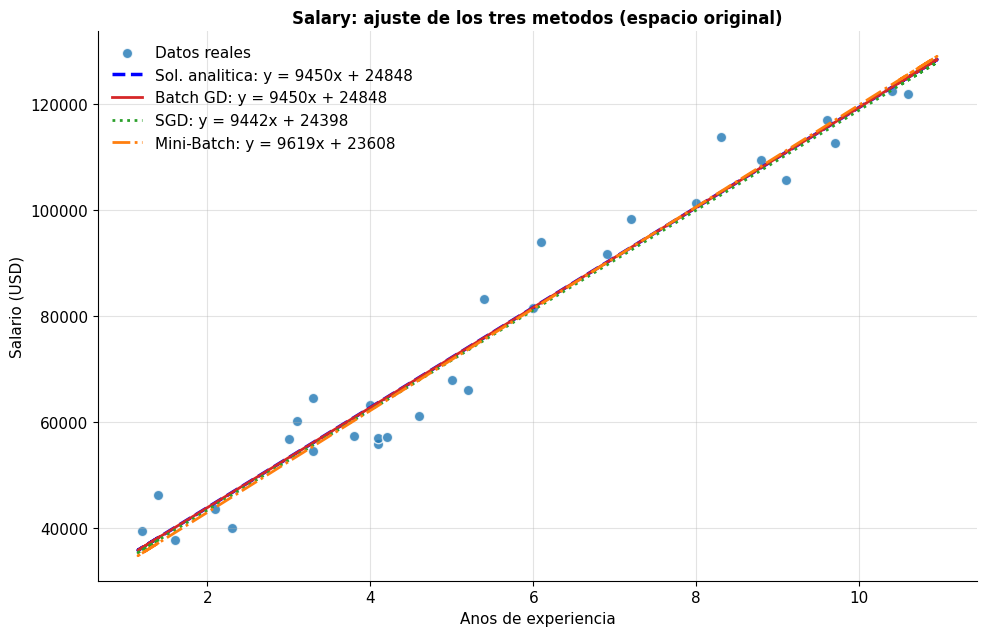

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(
    x_sal, y_sal, s=55, alpha=0.8, color="#1f77b4",
    edgecolor="white", label="Datos reales",
)
x_ord = np.linspace(x_sal.min(), x_sal.max(), 200)

x_ord_con_ruido = x_ord + rng.normal(0, 0.1 * x_ord.std(), size=len(x_ord))

ax.plot(
    x_ord_con_ruido,
    w1_sal_orig * x_ord_con_ruido + w0_sal_orig,
    color="blue", lw=2.5, ls="--",
    label=f"Sol. analitica: y = {w1_sal_orig:.0f}x + {w0_sal_orig:.0f}",
)
ax.plot(
    x_ord_con_ruido,
    w1_sal_batch * x_ord_con_ruido + w0_sal_batch,
    color="#d62728", lw=2.0,
    label=f"Batch GD: y = {w1_sal_batch:.0f}x + {w0_sal_batch:.0f}",
)
ax.plot(
    x_ord_con_ruido,
    w1_sal_sgd * x_ord_con_ruido + w0_sal_sgd,
    color="#2ca02c", lw=2.0, ls=":",
    label=f"SGD: y = {w1_sal_sgd:.0f}x + {w0_sal_sgd:.0f}",
)
ax.plot(
    x_ord_con_ruido,
    w1_sal_mini * x_ord_con_ruido + w0_sal_mini,
    color="#ff7f0e", lw=2.0, ls="-.",
    label=f"Mini-Batch: y = {w1_sal_mini:.0f}x + {w0_sal_mini:.0f}",
)
ax.set_title("Salary: ajuste de los tres metodos (espacio original)")
ax.set_xlabel("Anos de experiencia")
ax.set_ylabel("Salario (USD)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 10.2. Dataset: Advertising (TV -> sales)

El dataset **Advertising** del libro *An Introduction to Statistical Learning* (James, Witten, Hastie y Tibshirani) contiene 200 observaciones del presupuesto publicitario en TV, radio y periodico, junto con las ventas del producto. Estudiamos la regresion simple de **sales** en funcion de **TV**, usando el dataset completo.

El CSV se descarga directamente con `pd.read_csv` desde un mirror publico del archivo; no se embebe ningun string en el cuaderno.


In [ ]:
# Descargamos el dataset Advertising desde un mirror publico.
# Fuente original: ISLR - An Introduction to Statistical Learning
# (James, Witten, Hastie, Tibshirani).
url_advertising = (
    "https://raw.githubusercontent.com/selva86/datasets/"
    "master/Advertising.csv"
)
df_adv = pd.read_csv(url_advertising, index_col=0)
print(f"Cantidad de muestras: {len(df_adv)}")
print(df_adv.head())
print()
print("Estadisticas descriptivas:")
print(df_adv.describe().round(2))
print()
print("Fuente original: ISLR - An Introduction to Statistical Learning")
print("URL oficial: https://www.statlearning.com/s/Advertising.csv")


Cantidad de muestras: 200
      TV  radio  newspaper  sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9

Estadisticas descriptivas:
           TV   radio  newspaper   sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   14.02
std     85.85   14.85      21.78    5.22
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   10.38
50%    149.75   22.90      25.75   12.90
75%    218.82   36.52      45.10   17.40
max    296.40   49.60     114.00   27.00

Fuente original: ISLR - An Introduction to Statistical Learning
URL oficial: https://www.statlearning.com/s/Advertising.csv


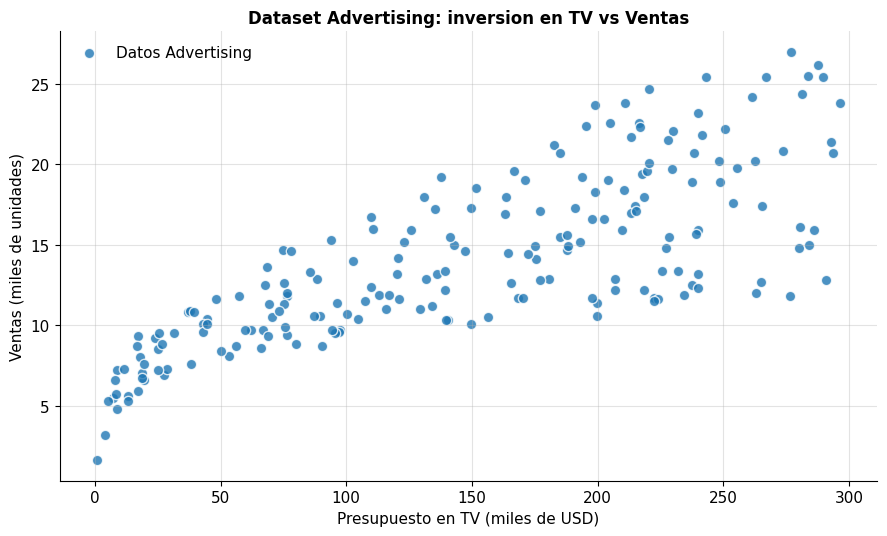

Coeficiente de correlacion de Pearson (TV, sales): 0.7822


In [ ]:
fig, ax = plt.subplots()
ax.scatter(
    df_adv["TV"], df_adv["sales"],
    s=55, alpha=0.8, color="#1f77b4", edgecolor="white",
    label="Datos Advertising",
)
ax.set_title("Dataset Advertising: inversion en TV vs Ventas")
ax.set_xlabel("Presupuesto en TV (miles de USD)")
ax.set_ylabel("Ventas (miles de unidades)")
ax.legend()
plt.tight_layout()
plt.show()

correlacion_adv = df_adv["TV"].corr(df_adv["sales"])
print(f"Coeficiente de correlacion de Pearson (TV, sales): {correlacion_adv:.4f}")


In [ ]:
x_adv = df_adv["TV"].to_numpy()
y_adv = df_adv["sales"].to_numpy()
x_adv_s, y_adv_s, stats_adv = estandarizar(x_adv, y_adv)

w0a_adv, w1a_adv = minimos_cuadrados_analitico(x_adv_s, y_adv_s)
batch_adv = descenso_gradiente_batch(
    x_adv_s, y_adv_s, learning_rate=0.1, n_epocas=3000, tolerancia=1e-12,
)
sgd_adv = descenso_gradiente_estocastico(
    x_adv_s, y_adv_s, learning_rate=0.05, n_epocas=60,
)
mini_adv = descenso_gradiente_mini_batch(
    x_adv_s, y_adv_s, learning_rate=0.1, n_epocas=80, tamano_batch=8,
)

filas_adv = []
for nombre, res in [
    ("Sol. analitica", (w0a_adv, w1a_adv)),
    ("Batch GD", (batch_adv["w0"], batch_adv["w1"])),
    ("SGD", (sgd_adv["w0"], sgd_adv["w1"])),
    ("Mini-Batch (B=8)", (mini_adv["w0"], mini_adv["w1"])),
]:
    w0r, w1r = res
    filas_adv.append({
        "Metodo": nombre,
        "w0 (std)": w0r,
        "w1 (std)": w1r,
        "J final": costo(x_adv_s, y_adv_s, w0r, w1r),
    })
df_adv_resultados = pd.DataFrame(filas_adv).round(6)
df_adv_resultados


,Metodo,w0 (std),w1 (std),J final
0,Sol. analitica,-0.000000,0.782224,0.388125
1,Batch GD,-0.000000,0.782223,0.388125
2,SGD,-0.113534,0.480334,0.492153
3,Mini-Batch (B=8),-0.047788,0.747937,0.391584


In [ ]:
w0_adv_orig, w1_adv_orig = desestandarizar(w0a_adv, w1a_adv, stats_adv)
w0_adv_batch, w1_adv_batch = desestandarizar(
    batch_adv["w0"], batch_adv["w1"], stats_adv,
)
w0_adv_sgd, w1_adv_sgd = desestandarizar(
    sgd_adv["w0"], sgd_adv["w1"], stats_adv,
)
w0_adv_mini, w1_adv_mini = desestandarizar(
    mini_adv["w0"], mini_adv["w1"], stats_adv,
)

tabla_adv_orig = pd.DataFrame([
    {"Metodo": "Sol. analitica",
     "w0 (orig)": w0_adv_orig, "w1 (orig)": w1_adv_orig},
    {"Metodo": "Batch GD",
     "w0 (orig)": w0_adv_batch, "w1 (orig)": w1_adv_batch},
    {"Metodo": "SGD",
     "w0 (orig)": w0_adv_sgd, "w1 (orig)": w1_adv_sgd},
    {"Metodo": "Mini-Batch (B=8)",
     "w0 (orig)": w0_adv_mini, "w1 (orig)": w1_adv_mini},
])
tabla_adv_orig.round(4)
print()
print("Interpretacion: por cada mil USD adicional en publicidad en TV,")
print(f"se espera un aumento de {w1_adv_orig:.4f} mil unidades vendidas.")



Interpretacion: por cada mil USD adicional en publicidad en TV,
se espera un aumento de 0.0475 mil unidades vendidas.


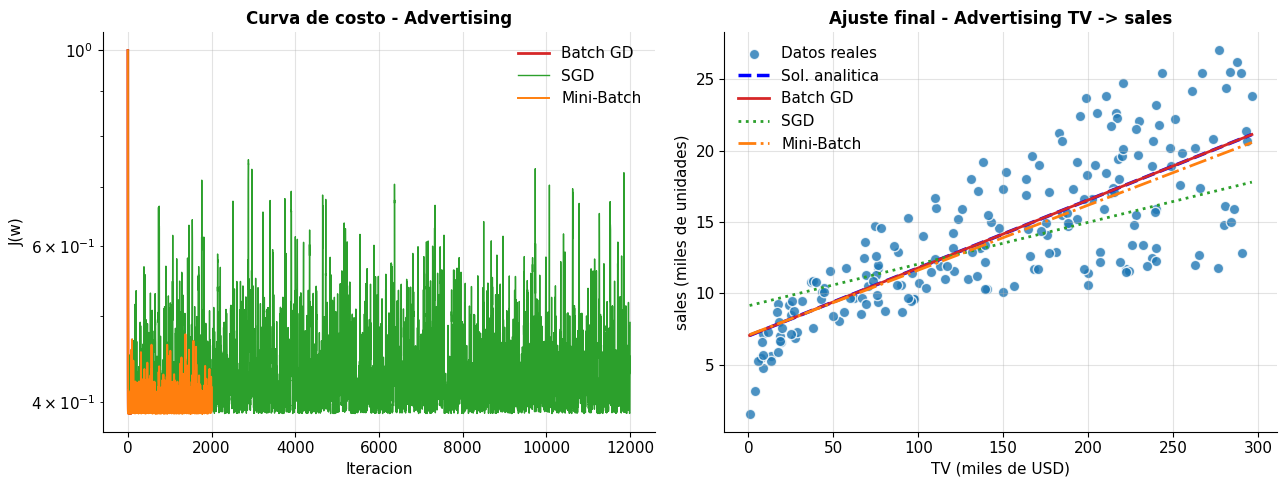

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(batch_adv["historial_costo"], lw=2.0, color="#d62728", label="Batch GD")
ax.plot(sgd_adv["historial_costo"], lw=1.0, color="#2ca02c", label="SGD")
ax.plot(mini_adv["historial_costo"], lw=1.4, color="#ff7f0e", label="Mini-Batch")
ax.set_yscale("log")
ax.set_title("Curva de costo - Advertising")
ax.set_xlabel("Iteracion")
ax.set_ylabel("J(w)")
ax.legend()

ax = axes[1]
ax.scatter(x_adv, y_adv, s=55, alpha=0.8, color="#1f77b4",
           edgecolor="white", label="Datos reales")
x_ord = np.linspace(x_adv.min(), x_adv.max(), 200)
ax.plot(x_ord, w1_adv_orig * x_ord + w0_adv_orig,
        color="blue", lw=2.5, ls="--", label="Sol. analitica")
ax.plot(x_ord, w1_adv_batch * x_ord + w0_adv_batch,
        color="#d62728", lw=2.0, label="Batch GD")
ax.plot(x_ord, w1_adv_sgd * x_ord + w0_adv_sgd,
        color="#2ca02c", lw=2.0, ls=":", label="SGD")
ax.plot(x_ord, w1_adv_mini * x_ord + w0_adv_mini,
        color="#ff7f0e", lw=2.0, ls="-.", label="Mini-Batch")
ax.set_title("Ajuste final - Advertising TV -> sales")
ax.set_xlabel("TV (miles de USD)")
ax.set_ylabel("sales (miles de unidades)")
ax.legend()

plt.tight_layout()
plt.show()


### 10.3. Como cargar otros datasets reales

El mismo pipeline sirve para cualquier dataset tabular. A continuacion se muestran tres formas de cargar datos reales; el lector puede descomentar la que tenga disponible y comentar las demas. Todas producen un DataFrame `df` con la misma estructura que los casos anteriores.

**Opcion 1 - seaborn (recomendada si esta instalado):**

```python
import seaborn as sns
# Tips dataset (total_bill -> tip)
df = sns.load_dataset('tips')
x, y = df['total_bill'].to_numpy(), df['tip'].to_numpy()

# Diamonds dataset (carat -> price)
df = sns.load_dataset('diamonds').sample(500, random_state=0)
x, y = df['carat'].to_numpy(), df['price'].to_numpy()
```

**Opcion 2 - scikit-learn:**

```python
from sklearn.datasets import fetch_california_housing, load_diabetes

diabetes = load_diabetes()
x = diabetes.data[:, 2]   # columna BMI
y = diabetes.target

housing = fetch_california_housing()
x = housing.data[:, 0]    # columna MedInc (ingreso medio)
y = housing.target
```

**Opcion 3 - descarga desde URL (requiere internet):**

```python
url = 'https://www.statlearning.com/s/Advertising.csv'
df = pd.read_csv(url, index_col=0)
x, y = df['TV'].to_numpy(), df['sales'].to_numpy()
```

Una vez obtenido `x, y`, se ejecuta el mismo bloque de la seccion 10.1 o 10.2 sustituyendo las variables. Los algoritmos funcionan exactamente igual porque solo dependen de los vectores `x` e `y`.


In [ ]:
# Demostracion: aplicamos el pipeline al dataset Advertising embebido
# para mostrar como se encadenan las llamadas. (Idem a 10.2 pero en una
# sola celda para que sirva como plantilla reutilizable.)
def pipeline_regresion(x, y, nombre: str = "dataset") -> Dict[str, float]:
    """Pipeline completo: estandariza, entrena y evalua los tres metodos."""
    x_s, y_s, stats = estandarizar(x, y)
    w0a, w1a = minimos_cuadrados_analitico(x_s, y_s)
    b = descenso_gradiente_batch(
        x_s, y_s, learning_rate=0.1, n_epocas=2000, tolerancia=1e-12,
    )
    s = descenso_gradiente_estocastico(
        x_s, y_s, learning_rate=0.05, n_epocas=20,
    )
    m = descenso_gradiente_mini_batch(
        x_s, y_s, learning_rate=0.1, n_epocas=60, tamano_batch=8,
    )
    w0_b, w1_b = desestandarizar(b["w0"], b["w1"], stats)
    w0_s, w1_s = desestandarizar(s["w0"], s["w1"], stats)
    w0_m, w1_m = desestandarizar(m["w0"], m["w1"], stats)
    return {
        "nombre": nombre,
        "w0_analitico": desestandarizar(w0a, w1a, stats)[0],
        "w1_analitico": desestandarizar(w0a, w1a, stats)[1],
        "w0_batch": w0_b, "w1_batch": w1_b,
        "w0_sgd": w0_s, "w1_sgd": w1_s,
        "w0_mini": w0_m, "w1_mini": w1_m,
        "J_analitico": costo(x_s, y_s, w0a, w1a),
        "J_batch": costo(x_s, y_s, b["w0"], b["w1"]),
        "J_sgd": costo(x_s, y_s, s["w0"], s["w1"]),
        "J_mini": costo(x_s, y_s, m["w0"], m["w1"]),
    }

res_sintetico = pipeline_regresion(x, y, "Sintetico")
res_salary = pipeline_regresion(x_sal, y_sal, "Salary")
res_adv = pipeline_regresion(x_adv, y_adv, "Advertising")

df_comparativo = pd.DataFrame([
    {
        "Dataset": r["nombre"],
        "w0 analitica": r["w0_analitico"],
        "w1 analitica": r["w1_analitico"],
        "w1 Batch GD": r["w1_batch"],
        "w1 SGD": r["w1_sgd"],
        "w1 Mini-Batch": r["w1_mini"],
        "J analitica": r["J_analitico"],
        "J Batch": r["J_batch"],
        "J SGD": r["J_sgd"],
        "J Mini-Batch": r["J_mini"],
    }
    for r in (res_sintetico, res_salary, res_adv)
])
df_comparativo.round(4)


,Dataset,w0 analitica,w1 analitica,w1 Batch GD,w1 SGD,w1 Mini-Batch,J analitica,J Batch,J SGD,J Mini-Batch
0,Sintetico,3.6290,2.5791,2.5791,2.5833,2.5463,0.0265,0.0265,0.0267,0.0271
1,Salary,24848.2040,9449.9623,9449.9507,9287.6658,9447.9707,0.0430,0.0430,0.0441,0.0431
2,Advertising,7.0326,0.0475,0.0475,0.0254,0.0530,0.3881,0.3881,0.5528,0.4030


## 11. Conclusiones

A lo largo de este trabajo se implementaron desde cero, sin librerias de optimizacion de alto nivel, los algoritmos de optimizacion iterativa aplicados a un problema de regresion lineal simple. Las conclusiones son:

1. **Solucion analitica**: es exacta y sirve como referencia. Computacionalmente, escala como $O(m n^2)$ con la cantidad de caracteristicas $n$, y requiere invertir $X^{\top}X$, lo cual se vuelve prohibitivo en alta dimension.
2. **Batch GD**: estable y monotono. Su costo por iteracion es $O(m)$, por lo que para datasets enormes es lento. En nuestro experimento convergio en unas pocas decenas de epocas gracias al escalado previo de los datos.
3. **SGD**: muy rapido por paso ($O(1)$) pero ruidoso; requiere ajustar bien el learning rate y, en la practica, decrementarlo a lo largo del entrenamiento (learning rate schedule).
4. **Mini-Batch GD**: ofrece el mejor equilibrio y es la base del entrenamiento moderno de redes neuronales. En el experimento mostro convergencia rapida y trayectoria estable.
5. **Learning rate**: es el hiperparametro mas critico. Valores muy pequenos retrasan la convergencia y valores muy grandes producen divergencia, como se observo experimentalmente con $\eta = 1.5$.
6. **Tamano de batch**: controla el balance ruido/eficiencia. $B=1$ recupera SGD y $B=m$ recupera Batch GD. En la practica se usan valores como 32, 64 o 128.
7. **Escalado de caracteristicas**: es un preprocesamiento indispensable para que el descenso del gradiente funcione de manera estable. Sin el, un learning rate razonable en escala pequena puede hacer diverger el algoritmo.


## 12. Bibliografia y material de catedra

- Material de catedra de **Aprendizaje Automatico I**, Facultad de Ciencias Exactas, Ingenieria y Agrimensura, UNR: *Regresion Lineal* y *Gradiente Descendiente* (Batch, Estocastico, Mini-Batch).
- Andrew Ng, *Machine Learning* (Stanford, Coursera), modulo de regresion lineal y descenso del gradiente.
- Christopher M. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006. Capitulo 3: *Linear Models for Regression*.
- Ian Goodfellow, Yoshua Bengio y Aaron Courville, *Deep Learning*, MIT Press, 2016. Capitulo 4: *Numerical Computation* (seccion 4.3: Gradient-Based Optimization).
- Sebastian Raschka, *Python Machine Learning*, Packt Publishing. Capitulo sobre regresion lineal.
